# 🚚 End-to-End Logistics Analytics Project

## 1️⃣ Project Overview

This project presents an end-to-end analytics solution for a logistics and transportation operation, designed to transform raw operational data into actionable business insights.
The analysis covers key operational, financial, and risk-focused areas such as driver performance, route profitability, fleet utilization, maintenance efficiency, fuel costs, customer value, safety incidents, and seasonal trends.

The project emphasizes **normalized metrics, cost vs revenue analysis, and risk classification**, ensuring insights are decision-ready rather than purely descriptive.
All analyses are performed using Python (pandas, matplotlib, seaborn) and structured to reflect real-world industry workflows.

---

## 2️⃣ Table of Contents

1. **Driver Performance Analysis**
   - Trips, distance, fuel efficiency, and on-time performance

2. **Route Profitability: Revenue vs Cost by Lane**
   - Revenue normalization, pricing variance, fuel cost estimation, and route health

3. **Fleet Utilization Analysis**
   - Asset usage, downtime, availability, and utilization efficiency

4. **Maintenance Cost & Downtime Analysis**
   - Maintenance cost per mile and operational impact

5. **Fuel Efficiency Analysis**
   - MPG trends, fuel cost per mile, and fuel recovery

6. **Customer Revenue & Service Analysis**
   - Revenue concentration, service levels, and customer value

7. **Safety Metrics & Risk Analysis**
   - Incident severity, preventability, cost impact, and risk classification

8. **Seasonal Pattern Analysis**
   - Monthly and seasonal trends in incidents and costs

9. **Final Insights & Business Recommendations**
   - Key findings, limitations, and next steps



In [165]:
from mermaid import Mermaid

diagram = """
graph TD

    %% Core entities
    Customer[Customer]
    Route[Route]
    Load[Load]
    Trip[Trip]
    Driver[Driver]
    Truck[Truck]
    Trailer[Trailer]

    %% Operational entities
    Fuel[Fuel Purchases]
    Maintenance[Maintenance Records]
    Delivery[Delivery Events]
    Safety[Safety Incidents]

    %% Relationships
    Customer --> Load
    Route -->Load

    Load -->Trip

    Driver --> Trip
    Truck -->Trip
    Trailer -->Trip

    Fuel --> Trip
    Delivery -->Trip
    Safety -->Trip

    Maintenance --> Truck
"""

Mermaid(diagram)


In [166]:
import pandas as pd
import numpy as np

pd.options.display.float_format = "{:.2f}".format


In [167]:
#load all the files

drivers_df = pd.read_csv("../Data/raw/drivers.csv")
trips_df = pd.read_csv("../Data/raw/trips.csv")
fuel_purchases_df = pd.read_csv("../Data/raw/fuel_purchases.csv")
loads_df = pd.read_csv("../Data/raw/loads.csv")
trucks_df = pd.read_csv("../Data/raw/trucks.csv")
delivery_events_df= pd.read_csv("../Data/raw/delivery_events.csv")
driver_monthly_metrics_df = pd.read_csv('../Data/raw/driver_monthly_metrics.csv')
route_df = pd.read_csv('../Data/raw/routes.csv')
trailer_df = pd.read_csv('../Data/raw/trailers.csv')
truck_utilization_metrics_df = pd.read_csv('../Data/raw/truck_utilization_metrics.csv')
facilities_df = pd.read_csv('../Data/raw/facilities.csv')
customers_df = pd.read_csv('../Data/raw/customers.csv')
safety_incident_df = pd.read_csv('../Data/raw/safety_incidents.csv')

In [168]:
trips_df.head()


,trip_id,load_id,driver_id,truck_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status
0,TRIP00000001,LOAD00000001,DRV00117,TRK00035,TRL00167,2022-01-01,1314,26.20,183.80,7.15,3.50,Completed
1,TRIP00000002,LOAD00000002,DRV00141,TRK00108,TRL00082,2022-01-01,515,8.60,93.60,5.50,8.30,Completed
2,TRIP00000003,LOAD00000003,DRV00032,TRK00031,TRL00138,2022-01-01,2509,45.00,339.10,7.40,12.00,Completed
3,TRIP00000004,LOAD00000004,DRV00083,TRK00105,TRL00018,2022-01-01,717,11.10,110.30,6.50,9.60,Completed
4,TRIP00000005,LOAD00000005,DRV00044,TRK00076,TRL00054,2022-01-01,2243,35.00,328.90,6.82,11.60,Completed


In [169]:
def data_quality_report(df):
    total_rows = len(df)
    missing_summary = []

    print("📊 DATA QUALITY REPORT")
    print("="*60)

    # Loop through each column
    for col in df.columns:
        missing = df[col].isna().sum()
        percent = (missing / total_rows) * 100

        if missing == 0:
            status = "✅"
            line = f"{status} {col:<40}: Complete"
        else:
            status = "❌"
            line = f"{status} {col:<40}: {missing:,} missing ({percent:.1f}%)"

        print(line)
        missing_summary.append((col, missing, percent))

    # Compute overall completeness
    total_cells = df.shape[0] * df.shape[1]
    total_missing = df.isna().sum().sum()
    completeness = 100 * (1 - total_missing / total_cells)

    print(f"\n📈 Overall Data Completeness: {completeness:.1f}%")

    return pd.DataFrame(missing_summary, columns=['Column', 'Missing', 'Missing_%']).sort_values(by='Missing_%', ascending=False)

In [170]:
data_quality_report(trips_df)

📊 DATA QUALITY REPORT
✅ trip_id                                 : Complete
✅ load_id                                 : Complete
❌ driver_id                               : 1,714 missing (2.0%)
❌ truck_id                                : 1,672 missing (2.0%)
❌ trailer_id                              : 1,680 missing (2.0%)
✅ dispatch_date                           : Complete
✅ actual_distance_miles                   : Complete
✅ actual_duration_hours                   : Complete
✅ fuel_gallons_used                       : Complete
✅ average_mpg                             : Complete
✅ idle_time_hours                         : Complete
✅ trip_status                             : Complete

📈 Overall Data Completeness: 99.5%


,Column,Missing,Missing_%
2,driver_id,1714,2.01
4,trailer_id,1680,1.97
3,truck_id,1672,1.96
1,load_id,0,0.00
0,trip_id,0,0.00
5,dispatch_date,0,0.00
6,actual_distance_miles,0,0.00
7,actual_duration_hours,0,0.00
8,fuel_gallons_used,0,0.00
9,average_mpg,0,0.00


In [171]:
drivers_df.head()

,driver_id,first_name,last_name,hire_date,termination_date,license_number,license_state,date_of_birth,home_terminal,employment_status,cdl_class,years_experience
0,DRV00001,Jennifer,Hernandez,2014-10-31,NaN,DL673510887,WA,1973-11-07,Denver,Active,A,3
1,DRV00002,William,Martin,2020-10-02,NaN,DL128955006,GA,1976-11-03,Columbus,Active,A,20
2,DRV00003,Charles,Hernandez,2021-09-21,NaN,DL523076025,NC,1970-04-06,Salt Lake City,Active,A,19
3,DRV00004,Barbara,Brown,2013-09-08,NaN,DL735540030,WA,1995-02-06,Denver,Active,A,19
4,DRV00005,Mary,Martinez,2018-12-02,NaN,DL706011277,AZ,1960-07-15,Chicago,Active,A,12


In [172]:
print(f"drive shape :{drivers_df.shape}")
print(f"trips shape :{trips_df.shape}")
print(f"loads shape :{loads_df.shape}")
print(f"trucks shape :{trucks_df.shape}")
print(f"delivery_events shape :{delivery_events_df.shape}")

drive shape :(150, 12)
trips shape :(85410, 12)
loads shape :(85410, 12)
trucks shape :(120, 11)
delivery_events shape :(170820, 11)


## 📈 Year-over-Year (YoY) Growth & Trend Classification

### Purpose
To evaluate how revenue (or any numeric metric) changes over time and to classify whether the trend is improving, declining, or stable.

This analysis was applied to **routes, trucks, and drivers** using yearly aggregated data.

---

### YoY Growth Calculation (Dynamic & Safe)

The YoY growth function calculates the percentage change between consecutive years while safely handling missing years or zero values.

**Formula used:**

\[
\text{YoY Growth} = \frac{\text{Current Year Value} - \text{Previous Year Value}}{\text{Previous Year Value}}
\]

**Key characteristics:**
- Automatically detects available years (no hard-coding of 2022, 2023, etc.)
- Avoids division by zero
- Returns `NaN` when growth cannot be calculated safely

This ensures consistent and reliable growth metrics across different entities.

---

### Multi-Year Trend Classification

After computing YoY growth, a trend classification function is applied to summarize overall performance across multiple years.

**Logic used:**
- **Growing** → Majority of YoY values are positive
- **Declining** → Majority of YoY values are negative
- **Stable** → Mixed or near-zero changes
- **No Trend** → Insufficient or missing data

This converts raw growth numbers into **interpretable business labels**.

---

### Why This Approach Was Used

- Prevents misleading results from missing or zero baseline values
- Works across different datasets without modification
- Converts numeric growth into decision-ready trend categories

---

### Outcome
Each entity (route, truck, driver) is assigned:
- Year-wise revenue values
- YoY growth percentages
- A final **trend label** summarizing performance over time

This allows quick identification of consistently growing, declining, or stable entities.


In [173]:
def calc_yoy_growth_dynamic_safe(df, id_col="id", year_col="year", value_col="revenue"):
    """
    Robustly pivot (driver,year,value) -> driver rows with rev_{year}, yoy_{prev}_{cur}, cagr_{start}_{end}.
    Returns DataFrame. Raises informative errors if input is missing required cols.
    """
    # Basic checks
    if not isinstance(df, pd.DataFrame):
        raise TypeError("Input must be a pandas DataFrame.")
    for c in (id_col, year_col, value_col):
        if c not in df.columns:
            raise KeyError(f"Required column not found in dataframe: '{c}'")

    # Work on a copy
    df_in = df[[id_col, year_col, value_col]].copy()

    # Clean year column: attempt to extract integer year; if not possible, keep as-is but ensure sortable
    # We will create a helper column `__year_val` for sorting/pivot
    def to_year_val(x):
        # handle pandas Timestamps, strings like '2022-01-01', ints, or '2022'
        if pd.isna(x):
            return np.nan
        if isinstance(x, (pd.Timestamp, pd.DatetimeTZDtype, )):
            return x.year
        try:
            # numeric strings or ints
            xi = int(x)
            return xi
        except Exception:
            # try parsing as date string
            try:
                return pd.to_datetime(x, errors='coerce').year
            except Exception:
                return np.nan

    df_in["__year_val"] = df_in[year_col].apply(to_year_val)

    # If __year_val is mostly NaN (cannot parse), fallback to raw year_col values but sorted as strings
    if df_in["__year_val"].notna().sum() < len(df_in) * 0.2:
        # many unparsable, use raw values (converted to string) for grouping
        df_in["__year_key"] = df_in[year_col].astype(str)
        sort_years = sorted(df_in["__year_key"].unique())
        pivot = df_in.pivot_table(index=id_col, columns="__year_key", values=value_col, aggfunc="sum").reindex(columns=sort_years)
        # rename to rev_{label}
        pivot.columns = [f"rev_{str(c)}" for c in pivot.columns]
        pivot = pivot.reset_index()
        return pivot

    # Otherwise use integer years for pivot
    # Drop rows where __year_val is NaN (can't attribute to a year)
    df_in = df_in[~df_in["__year_val"].isna()].copy()
    df_in["__year_val"] = df_in["__year_val"].astype(int)

    # Pivot: rows=id_col, cols=year int
    pivot = df_in.pivot_table(index=id_col, columns="__year_val", values=value_col, aggfunc="sum").sort_index(axis=1)

    # Rename revenue columns to rev_{year}
    pivot = pivot.rename(columns=lambda y: f"rev_{y}")

    # Create a list of available years in ascending order
    rev_cols = [c for c in pivot.columns if str(c).startswith("rev_")]
    years = [int(c.split("_",1)[1]) for c in rev_cols]

    # Compute YoY for each consecutive pair
    for i in range(1, len(years)):
        prev_col = f"rev_{years[i-1]}"
        cur_col  = f"rev_{years[i]}"
        yoy_col  = f"yoy_{years[i-1]}_{years[i]}"

        prev = pivot[prev_col]
        cur  = pivot[cur_col]

        # safe computation: where prev is NaN or prev == 0 -> result NaN
        mask = prev.notna() & (prev != 0)
        yoy = pd.Series(np.nan, index=pivot.index, dtype=float)
        if mask.any():
            yoy.loc[mask] = ((cur.loc[mask] - prev.loc[mask]) / prev.loc[mask]) * 100.0
        pivot[yoy_col] = yoy.round(2)

    # Compute CAGR between first and last year if possible
    if len(years) >= 2:
        start_col = f"rev_{years[0]}"
        end_col   = f"rev_{years[-1]}"
        cagr_col  = f"cagr_{years[0]}_{years[-1]}"
        start_vals = pivot[start_col]
        end_vals   = pivot[end_col]
        cagr = pd.Series(np.nan, index=pivot.index, dtype=float)
        valid = start_vals.notna() & end_vals.notna() & (start_vals > 0)
        if valid.any():
            n_periods = years[-1] - years[0]
            cagr.loc[valid] = ((end_vals.loc[valid] / start_vals.loc[valid]) ** (1.0 / n_periods) - 1.0) * 100.0
        pivot[cagr_col] = cagr.round(2)

    # Reset index to make driver_id a column
    pivot = pivot.reset_index()
    return pivot


In [174]:
def classify_trend_safe(pivot_df, id_col="id",
                               pos_threshold=5.0, neg_threshold=-5.0, stable_abs=5.0):
    """
    Classify drivers based on available YoY columns in pivot_df.
    Returns pivot_df with new 'trend_label' column.
    """
    if id_col not in pivot_df.columns:
        raise KeyError(f"driver_col '{id_col}' not in DataFrame")

    df = pivot_df.copy()
    # identify YoY columns
    yoy_cols = [c for c in df.columns if str(c).startswith("yoy_")]
    # If none present, label and exit
    if len(yoy_cols) == 0:
        df["trend_label"] = "No Trend Data"
        return df

    # Ensure consistent order by parsing years from column names when possible
    def _parse_yoy(col):
        try:
            parts = col.split("_")
            return int(parts[1]), int(parts[2])
        except Exception:
            return (0,0)
    yoy_cols = sorted(yoy_cols, key=_parse_yoy)

    labels = []
    for _, row in df.iterrows():
        vals = []
        for c in yoy_cols:
            v = row.get(c, np.nan)
            try:
                v = float(v)
            except Exception:
                v = np.nan
            vals.append(v)
        vals_arr = np.array(vals, dtype=float)
        finite_mask = np.isfinite(vals_arr)
        n_total = finite_mask.sum()
        if n_total == 0:
            labels.append("No Trend Data")
            continue

        n_pos_strong = np.sum(vals_arr > pos_threshold)
        n_pos_any = np.sum(vals_arr > 0)
        n_neg_strong = np.sum(vals_arr < neg_threshold)
        n_near = np.sum(np.isfinite(vals_arr) & (np.abs(vals_arr) <= stable_abs))

        recent = vals_arr[-1] if np.isfinite(vals_arr[-1]) else np.nan
        prev = vals_arr[-2] if len(vals_arr) >= 2 and np.isfinite(vals_arr[-2]) else np.nan

        # Apply rules (customize thresholds above)
        if n_total == n_near:
            label = "Stable"
        elif (n_pos_strong >= (n_total / 2.0)) and (not np.isnan(recent)) and recent >= pos_threshold:
            label = "Strong Upward"
        elif (n_pos_any > n_neg_strong) and n_pos_any > 0:
            label = "Upward"
        elif (n_neg_strong >= (n_total / 2.0)) and (not np.isnan(recent)) and recent <= neg_threshold:
            label = "Declining"
        elif (not np.isnan(recent) and recent >= pos_threshold) and (not np.isnan(prev) and prev < 0):
            label = "Recovery"
        else:
            label = "Volatile"
        labels.append(label)

    df["trend_label"] = labels
    return df


In [175]:
import matplotlib.pyplot as plt

def plot_best_worst_entities(
    df,
    id_col,
    metric_col,
    title_prefix,
    top_n=10,
    higher_is_better=True
):
    """
    Plots Best vs Worst entities for a given metric using independent subplots.

    Parameters:
    - df: DataFrame
    - id_col: Column name for entity ID (driver_id / truck_id / route_id)
    - metric_col: Metric column to rank by
    - title_prefix: Metric display name
    - top_n: Number of entities to display
    - higher_is_better: True if higher metric is better, False if lower is better
    """

    ascending = not higher_is_better

    sorted_df = df.sort_values(by=metric_col, ascending=ascending)

    best = sorted_df.head(top_n)
    worst = sorted_df.tail(top_n)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # BEST
    axes[0].bar(
        best[id_col].astype(str),
        best[metric_col]
    )
    axes[0].set_title(f"Best {title_prefix}")
    axes[0].set_xlabel(id_col.replace('_', ' ').title())
    axes[0].set_ylabel(title_prefix)
    axes[0].tick_params(axis='x', rotation=45)

    # WORST
    axes[1].bar(
        worst[id_col].astype(str),
        worst[metric_col]
    )
    axes[1].set_title(f"Worst {title_prefix}")
    axes[1].set_xlabel(id_col.replace('_', ' ').title())
    axes[1].set_ylabel(title_prefix)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


**Driver Performance Analysis**

In [176]:
driver_trip_join = trips_df.merge(drivers_df['driver_id'],on="driver_id",how='left')
driver_trip_join.head()

,trip_id,load_id,driver_id,truck_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status
0,TRIP00000001,LOAD00000001,DRV00117,TRK00035,TRL00167,2022-01-01,1314,26.20,183.80,7.15,3.50,Completed
1,TRIP00000002,LOAD00000002,DRV00141,TRK00108,TRL00082,2022-01-01,515,8.60,93.60,5.50,8.30,Completed
2,TRIP00000003,LOAD00000003,DRV00032,TRK00031,TRL00138,2022-01-01,2509,45.00,339.10,7.40,12.00,Completed
3,TRIP00000004,LOAD00000004,DRV00083,TRK00105,TRL00018,2022-01-01,717,11.10,110.30,6.50,9.60,Completed
4,TRIP00000005,LOAD00000005,DRV00044,TRK00076,TRL00054,2022-01-01,2243,35.00,328.90,6.82,11.60,Completed


In [177]:
driver_trip_join['dispatch_date'] = pd.to_datetime(driver_trip_join['dispatch_date'],errors='coerce')
driver_trip_join['year'] = driver_trip_join['dispatch_date'].dt.year

In [178]:
driver_performance = driver_trip_join.groupby(['driver_id','year']).agg(
    Total_trip = ('trip_id','count'),
    Total_distance_miles = ('actual_distance_miles','sum'),
    Total_time_hours = ('actual_duration_hours','sum'),
    Total_fuel_gallons_used = ('fuel_gallons_used','sum'),
).reset_index()
driver_performance.head(10)

,driver_id,year,Total_trip,Total_distance_miles,Total_time_hours,Total_fuel_gallons_used
0,DRV00001,2022,206,299421,5271.00,47164.10
1,DRV00001,2023,213,315819,5538.40,48998.70
2,DRV00001,2024,213,314996,5489.40,48543.10
3,DRV00002,2022,216,297805,5234.80,46272.20
4,DRV00002,2023,220,326958,5669.20,51197.20
5,DRV00002,2024,226,318483,5597.50,49131.30
6,DRV00003,2022,228,343957,5997.70,53389.10
7,DRV00003,2023,249,368078,6385.90,56552.70
8,DRV00003,2024,200,298200,5215.00,45956.00
9,DRV00004,2022,237,355150,6159.70,54927.50


In [179]:
avg_fuel_price = fuel_purchases_df['price_per_gallon'].mean()
driver_performance['fuel_cost'] = driver_performance['Total_fuel_gallons_used'] * avg_fuel_price
driver_performance['Mpg'] = driver_performance['Total_distance_miles']/driver_performance['Total_fuel_gallons_used']
driver_performance['fuel_used_per_miles'] = driver_performance['fuel_cost']/driver_performance['Total_distance_miles']
driver_performance.head()

,driver_id,year,Total_trip,Total_distance_miles,Total_time_hours,Total_fuel_gallons_used,fuel_cost,Mpg,fuel_used_per_miles
0,DRV00001,2022,206,299421,5271.00,47164.10,183865.38,6.35,0.61
1,DRV00001,2023,213,315819,5538.40,48998.70,191017.42,6.45,0.60
2,DRV00001,2024,213,314996,5489.40,48543.10,189241.30,6.49,0.60
3,DRV00002,2022,216,297805,5234.80,46272.20,180388.38,6.44,0.61
4,DRV00002,2023,220,326958,5669.20,51197.20,199588.09,6.39,0.61


## 🏆 Driver Performance Leaderboard

### Purpose
To rank drivers fairly based on **productivity, efficiency, and cost control**, using normalized metrics instead of raw totals.

---

### Key Metrics Used

**1. Trips Completed**
\[
\text{Total Trips} = \sum \text{Trips}
\]

Measures driver productivity.

---

**2. Distance Efficiency**
\[
\text{Miles per Trip} = \frac{\text{Total Miles}}{\text{Total Trips}}
\]

Ensures comparison across short and long hauls.

---

**3. Fuel Efficiency (MPG)**
\[
\text{MPG} = \frac{\text{Total Miles}}{\text{Fuel Gallons Used}}
\]

Higher MPG indicates better driving efficiency.

---

**4. Fuel Cost per Mile**
\[
\text{Fuel Cost per Mile} = \frac{\text{Fuel Cost}}{\text{Total Miles}}
\]

Lower values indicate cost-efficient driving behavior.

---

**5. Time Efficiency**
\[
\text{Hours per Trip} = \frac{\text{Total Driving Hours}}{\text{Total Trips}}
\]

Captures operational efficiency and delay avoidance.

---

### Leaderboard Construction
Drivers are ranked using a combination of:
- Higher productivity (more trips)
- Higher efficiency (MPG, miles per trip)
- Lower operating cost (fuel cost per mile, hours per trip)

This approach avoids bias from route length or trip volume.

---

### Outcome
The leaderboard highlights **top-performing drivers** who balance productivity, efficiency, and cost control, supporting fair performance evaluation and incentive decisions.


In [180]:
from sklearn.preprocessing import MinMaxScaler

metrics_higher_better = [
    "Total_trip",
    "Total_distance_miles",
    "Mpg"
]

metrics_lower_better = [
    "Total_time_hours",
    "Total_fuel_gallons_used",
    "fuel_cost",
    "fuel_used_per_miles"
]

scaler = MinMaxScaler()

df = driver_performance.copy()

# HIGHER IS BETTER → normal min-max
for col in metrics_higher_better:
    df[f"score_{col}"] = scaler.fit_transform(df[[col]])


for col in metrics_lower_better:
    df[f"score_{col}"] = 1 - scaler.fit_transform(df[[col]])


weights = {
    "Total_trip": 0.20,
    "Total_distance_miles": 0.20,
    "Mpg": 0.25,
    "Total_time_hours": 0.10,
    "Total_fuel_gallons_used": 0.10,
    "fuel_cost": 0.10,
    "fuel_used_per_miles": 0.05
}
df["driver_score_raw"] = 0

for metric, weight in weights.items():
    df["driver_score_raw"] += df[f"score_{metric}"] * weight

df["driver_score_100"] = df["driver_score_raw"] * 100
df["rank"] = df["driver_score_100"].rank(ascending=False).astype(int)


leaderboard = df.sort_values("rank")[[
    "rank",
    "driver_id",
    "driver_score_100",
    "Total_trip",
    "Total_distance_miles",
    "Mpg",
    "Total_time_hours",
    "Total_fuel_gallons_used",
    "fuel_cost",
    "fuel_used_per_miles"
]]

display(leaderboard)
leaderboard.to_csv('../Data/processed/driver_leaderboard_driver.csv', index=False)


,rank,driver_id,driver_score_100,Total_trip,Total_distance_miles,Mpg,Total_time_hours,Total_fuel_gallons_used,fuel_cost,fuel_used_per_miles
225,1,DRV00092,67.58,239,332704,6.58,5837.20,50567.80,197134.43,0.59
268,2,DRV00109,64.07,221,312534,6.57,5485.30,47571.20,185452.43,0.59
344,3,DRV00141,64.06,245,349701,6.55,6098.50,53400.80,208178.65,0.60
146,4,DRV00059,64.02,256,370058,6.54,6442.00,56578.80,220567.82,0.60
320,5,DRV00128,62.21,240,342747,6.54,5983.70,52421.00,204358.98,0.60
...,...,...,...,...,...,...,...,...,...,...
312,368,DRV00126,35.62,221,321071,6.34,5620.50,50616.90,197325.84,0.61
82,369,DRV00033,35.50,228,319426,6.33,5534.80,50477.20,196781.23,0.62
280,370,DRV00113,34.85,223,330156,6.34,5784.10,52084.10,203045.60,0.61
0,371,DRV00001,34.63,206,299421,6.35,5271.00,47164.10,183865.38,0.61


In [181]:
driver_monthly_metrics_df['month'] = pd.to_datetime(driver_monthly_metrics_df['month'],errors='coerce')
driver_monthly_metrics_df['year'] = driver_monthly_metrics_df['month'].dt.year
driver_monthly_metrics_df.head()

,driver_id,month,trips_completed,total_miles,total_revenue,average_mpg,total_fuel_gallons,on_time_delivery_rate,average_idle_hours,year
0,DRV00001,2022-01-01,26,36620,79141.59,6.61,5574.70,0.39,8.20,2022
1,DRV00001,2022-02-01,9,13515,27133.87,6.69,2095.10,0.33,6.80,2022
2,DRV00001,2022-03-01,20,30361,62399.62,6.36,4792.20,0.55,7.50,2022
3,DRV00001,2022-04-01,19,28127,68161.13,6.61,4251.40,0.47,8.40,2022
4,DRV00001,2022-05-01,14,16071,36256.82,6.35,2573.10,0.21,6.80,2022


In [182]:
drivers_revenue = driver_monthly_metrics_df.groupby(['driver_id','year']).agg(
    sum_total_revenue = ('total_revenue','sum'),
    sum_total_miles = ('total_miles','sum')
).reset_index()

drivers_revenue.head()
drivers_revenue.to_csv('../Data/processed/driver_revenue.csv', index=False)


In [183]:
drivers_revenue_per_miles= driver_monthly_metrics_df.groupby(['driver_id']).agg(
    sum_total_revenue = ('total_revenue','sum'),
    sum_total_miles = ('total_miles','sum')
).reset_index()

drivers_revenue_per_miles['revenue_per_miles'] = drivers_revenue_per_miles['sum_total_revenue']/drivers_revenue_per_miles['sum_total_miles']



drivers_revenue_per_miles.head()

,driver_id,sum_total_revenue,sum_total_miles,revenue_per_miles
0,DRV00001,1985683.26,930236,2.13
1,DRV00002,2073621.50,943246,2.20
2,DRV00003,2146977.47,1010235,2.13
3,DRV00004,2119361.45,982625,2.16
4,DRV00005,2022357.46,923128,2.19


In [184]:
drivers_revenue_copy = drivers_revenue.copy()
# 2) call the robust pivot + YoY function
# Note: value_col is your revenue column name: 'sum_total_revenue'
trend_df = calc_yoy_growth_dynamic_safe(
    drivers_revenue_copy,
    id_col="driver_id",
    year_col="year",
    value_col="sum_total_revenue"
)

# 3) classify trends with default thresholds (change thresholds if needed)
trend_df_classified_driver = classify_trend_safe(
    trend_df,
    id_col="driver_id",
    pos_threshold=5.0,    # +5% defines "strong positive"
    neg_threshold=-5.0,   # -5% defines "strong negative"
    stable_abs=5.0        # within ±5% considered "stable"
)




trend_df_classified_driver['Total_revenue_of_3year'] = trend_df_classified_driver['rev_2022'] +trend_df_classified_driver['rev_2023']+trend_df_classified_driver['rev_2024']

# 4) inspect result
display(trend_df_classified_driver.head(10))

trend_df_classified_driver.to_csv('../Data/processed/driver_trend_classified.csv', index=False)
print("Output columns:", trend_df_classified_driver.columns.tolist())

__year_val,driver_id,rev_2022,rev_2023,rev_2024,yoy_2022_2023,yoy_2023_2024,cagr_2022_2024,trend_label,Total_revenue_of_3year
0,DRV00001,653491.18,665702.48,666489.60,1.87,0.12,0.99,Stable,1985683.26
1,DRV00002,673174.83,707543.55,692903.12,5.11,-2.07,1.45,Upward,2073621.50
2,DRV00003,741799.80,768879.59,636298.08,3.65,-17.24,-7.38,Declining,2146977.47
3,DRV00004,759447.54,663922.07,695991.84,-12.58,4.83,-4.27,Volatile,2119361.45
4,DRV00005,633591.33,594838.85,793927.28,-6.12,33.47,11.94,Strong Upward,2022357.46
5,DRV00006,668209.00,614471.63,665530.84,-8.04,8.31,-0.20,Strong Upward,1948211.47
6,DRV00009,744900.49,699767.62,629130.83,-6.06,-10.09,-8.10,Declining,2073798.94
7,DRV00010,714301.08,743100.59,687257.26,4.03,-7.51,-1.91,Declining,2144658.93
8,DRV00011,728107.44,687418.24,737870.87,-5.59,7.34,0.67,Strong Upward,2153396.55
9,DRV00012,639267.41,503044.27,607553.98,-21.31,20.78,-2.51,Strong Upward,1749865.66


Output columns: ['driver_id', 'rev_2022', 'rev_2023', 'rev_2024', 'yoy_2022_2023', 'yoy_2023_2024', 'cagr_2022_2024', 'trend_label', 'Total_revenue_of_3year']


In [185]:

driver_monthly_metrics_df.columns.tolist()

['driver_id',
 'month',
 'trips_completed',
 'total_miles',
 'total_revenue',
 'average_mpg',
 'total_fuel_gallons',
 'on_time_delivery_rate',
 'average_idle_hours',
 'year']

In [186]:
driver_on_time_rate = driver_monthly_metrics_df.groupby(['driver_id']).agg(
    Total_trip =('trips_completed','sum'),
    Avg_on_time_delivery_rate = ('on_time_delivery_rate','mean')
).reset_index()

driver_on_time_rate.head()

,driver_id,Total_trip,Avg_on_time_delivery_rate
0,DRV00001,632,0.45
1,DRV00002,662,0.47
2,DRV00003,677,0.45
3,DRV00004,659,0.43
4,DRV00005,643,0.45


In [187]:

driver_on_time_rate['Avg_%driver_on_time_rate'] = driver_on_time_rate['Avg_on_time_delivery_rate']*100
driver_on_time_rate.head()

,driver_id,Total_trip,Avg_on_time_delivery_rate,Avg_%driver_on_time_rate
0,DRV00001,632,0.45,45.42
1,DRV00002,662,0.47,46.84
2,DRV00003,677,0.45,45.08
3,DRV00004,659,0.43,42.83
4,DRV00005,643,0.45,45.41


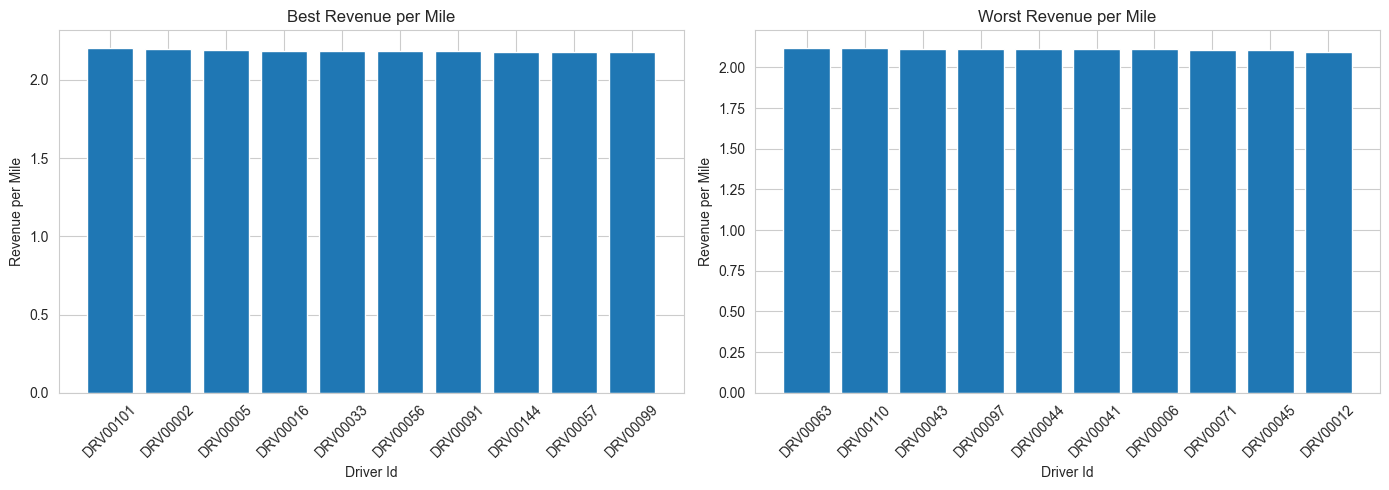

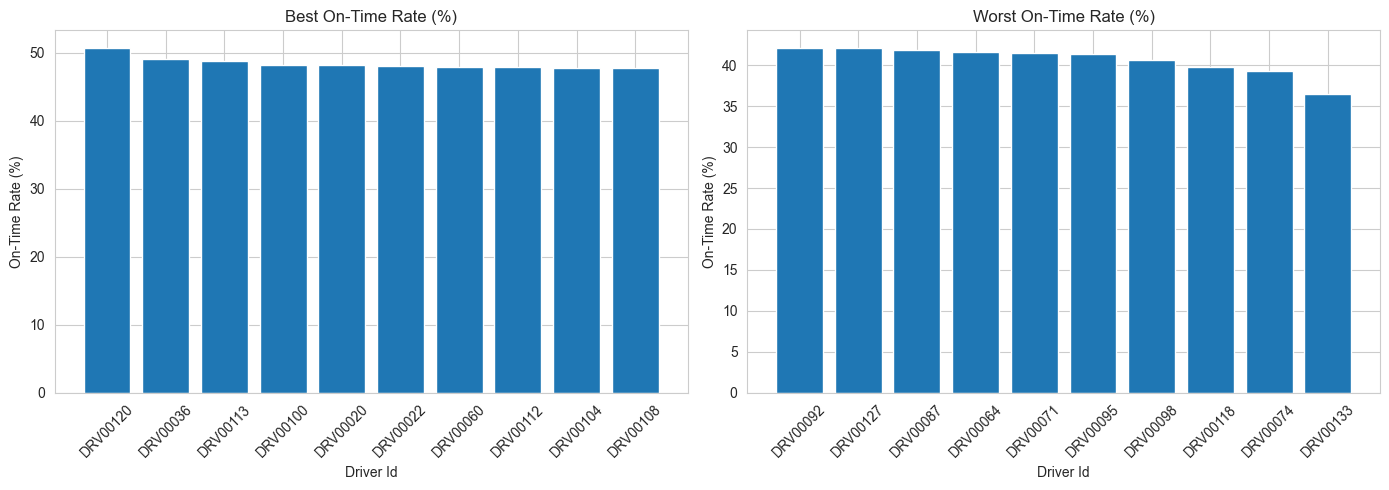

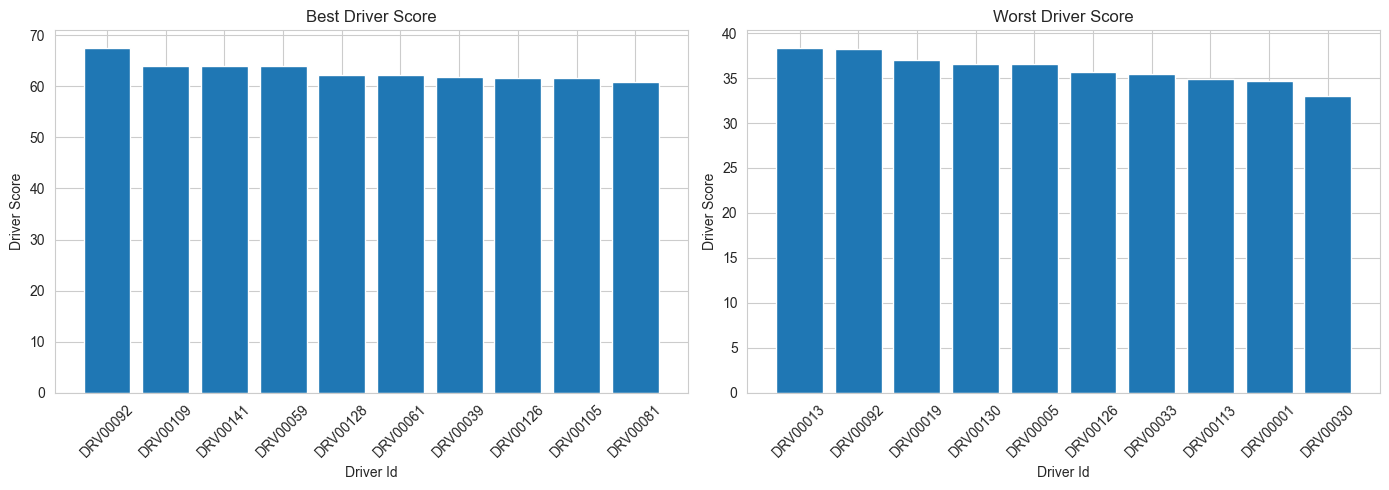

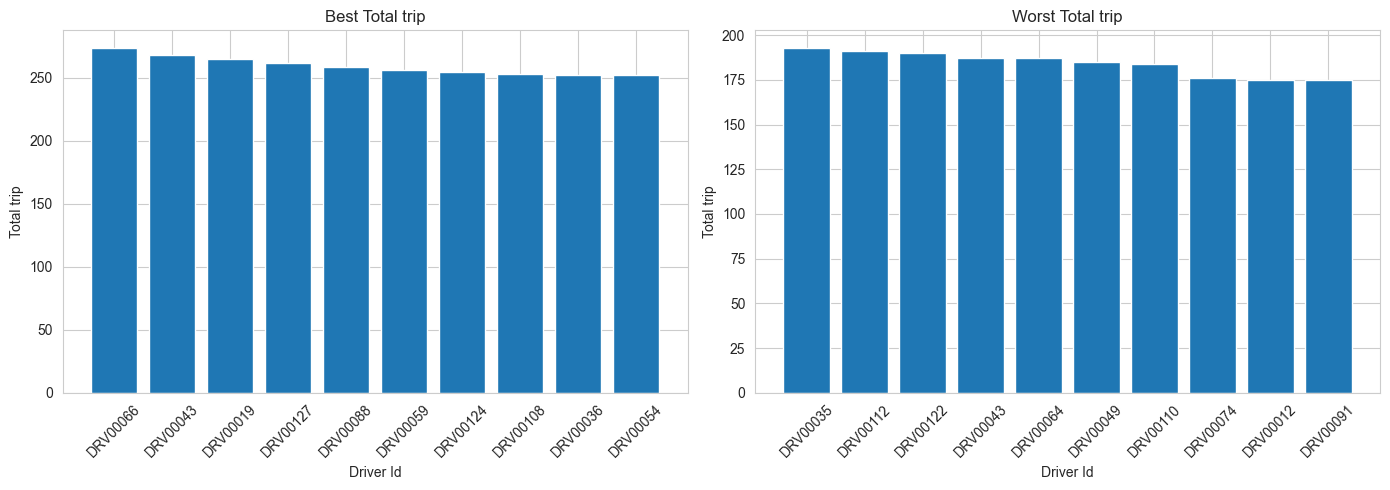

In [188]:
#Revenue_per_miles
plot_best_worst_entities(df=drivers_revenue_per_miles,
                         id_col='driver_id',
                         metric_col='revenue_per_miles',
                         title_prefix='Revenue per Mile',
                         higher_is_better=True
                         )
#Driver_on_time_rate
plot_best_worst_entities(df=driver_on_time_rate,
                         id_col='driver_id',
                         metric_col='Avg_%driver_on_time_rate',
                         title_prefix='On-Time Rate (%)',
                         higher_is_better=True
                         )
#Driver_score
plot_best_worst_entities(df=leaderboard,
                         id_col='driver_id',
                         metric_col='driver_score_100',
                         title_prefix='Driver Score',
                         higher_is_better=True
                         )
#Total_trip
plot_best_worst_entities(df=leaderboard,
                         id_col='driver_id',
                         metric_col='Total_trip',
                         title_prefix='Total trip',
                         higher_is_better=True
                         )



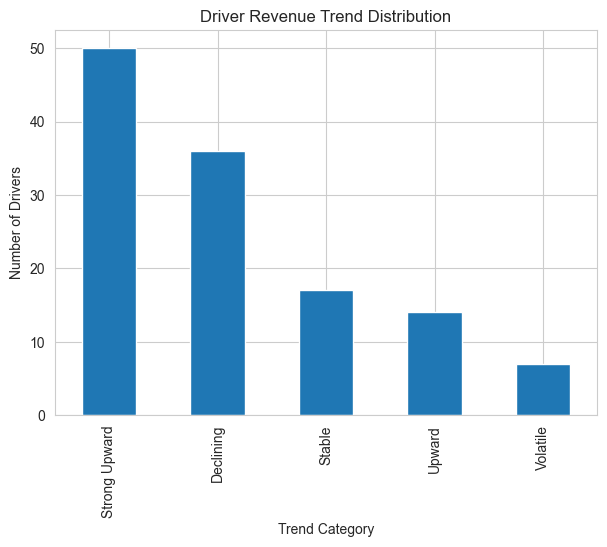

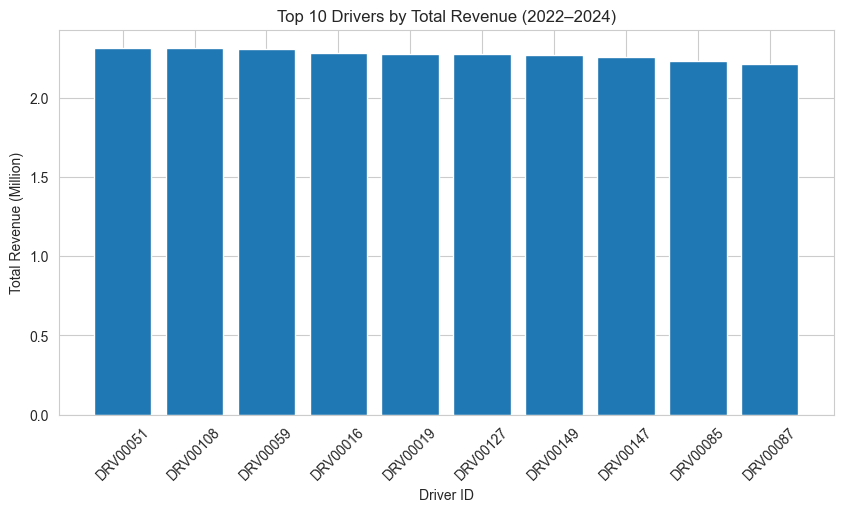

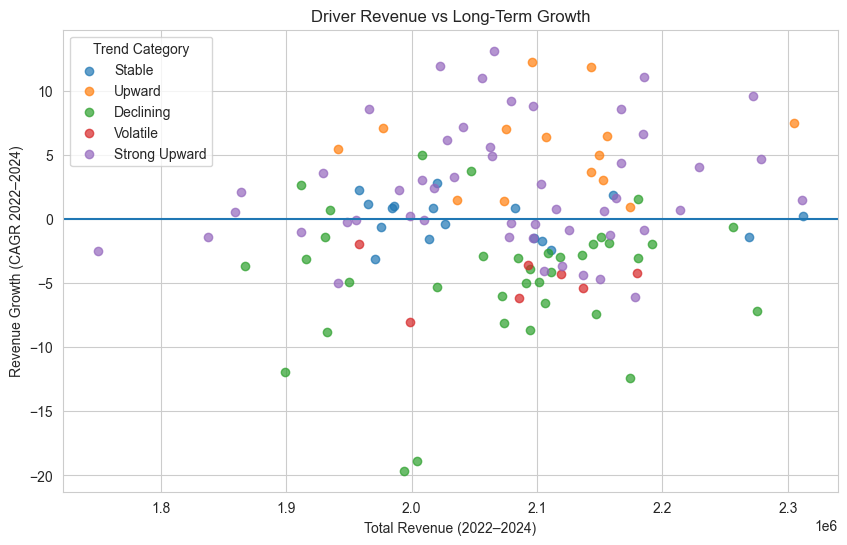

In [189]:
import matplotlib.pyplot as plt



#Graph 1: Trend Distribution (Count Bar Plot)
trend_counts = trend_df_classified_driver['trend_label'].value_counts()

plt.figure(figsize=(7, 5))
trend_counts.plot(kind='bar')
plt.xlabel("Trend Category")
plt.ylabel("Number of Drivers")
plt.title("Driver Revenue Trend Distribution")
plt.show()

top_drivers = (
    trend_df_classified_driver
    .sort_values('Total_revenue_of_3year', ascending=False)
    .head(10)
)


#2 Total Revenue by Driver (Top Contributors)
top_drivers = (
    trend_df_classified_driver
    .assign(total_rev_million=lambda x: x['Total_revenue_of_3year'] / 1_000_000)
    .sort_values('total_rev_million', ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(
    top_drivers['driver_id'].astype(str),
    top_drivers['total_rev_million']
)
plt.xlabel("Driver ID")
plt.ylabel("Total Revenue (Million)")
plt.title("Top 10 Drivers by Total Revenue (2022–2024)")
plt.xticks(rotation=45)
plt.show()



#Graph 3: Revenue vs Long-Term Growth (ONE-LOOK INSIGHT GRAPH)
plt.figure(figsize=(10, 6))

for trend in trend_df_classified_driver['trend_label'].unique():
    subset = trend_df_classified_driver[
        trend_df_classified_driver['trend_label'] == trend
    ]
    plt.scatter(
        subset['Total_revenue_of_3year'],
        subset['cagr_2022_2024'],
        label=trend,
        alpha=0.7
    )

plt.axhline(0)
plt.xlabel("Total Revenue (2022–2024)")
plt.ylabel("Revenue Growth (CAGR 2022–2024)")
plt.title("Driver Revenue vs Long-Term Growth")
plt.legend(title="Trend Category")
plt.show()


**Route Profitability: Revenue vs Cost by Lane**

In [190]:
route_df.head()


,route_id,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days
0,RTE00001,Atlanta,GA,Chicago,IL,677,1.70,0.19,1
1,RTE00002,Atlanta,GA,Miami,FL,697,2.08,0.22,1
2,RTE00003,Chicago,IL,Los Angeles,CA,2003,2.55,0.29,3
3,RTE00004,Chicago,IL,Portland,OR,2017,1.84,0.19,3
4,RTE00005,Chicago,IL,Las Vegas,NV,1749,2.41,0.26,3


In [191]:
loads_df.head()

,load_id,customer_id,route_id,load_date,load_type,weight_lbs,pieces,revenue,fuel_surcharge,accessorial_charges,load_status,booking_type
0,LOAD00000001,CUST00183,RTE00019,2022-01-01,Dry Van,19178,13,3045.23,406.72,100,Completed,Spot
1,LOAD00000002,CUST00076,RTE00058,2022-01-01,Dry Van,27761,22,1224.48,98.61,0,Completed,Dedicated
2,LOAD00000003,CUST00027,RTE00048,2022-01-01,Refrigerated,35594,16,7171.12,792.88,0,Completed,Spot
3,LOAD00000004,CUST00088,RTE00013,2022-01-01,Refrigerated,33274,10,1308.20,141.33,50,Completed,Spot
4,LOAD00000005,CUST00185,RTE00020,2022-01-01,Dry Van,40257,10,3317.18,738.48,0,Completed,Spot


In [192]:
loads_df['load_date'] = pd.to_datetime(loads_df['load_date'],errors='coerce')
loads_df['year'] =  loads_df['load_date'].dt.year

In [193]:
routes_groupby =  loads_df.groupby(['route_id','year']).agg(
    sum_total_revenue = ('revenue','sum'),
    sum_fuel_subcharge = ('fuel_surcharge','sum'),
    sum_acessorial_charges =('accessorial_charges','sum')
).reset_index()
routes_groupby.head()

,route_id,year,sum_total_revenue,sum_fuel_subcharge,sum_acessorial_charges
0,RTE00001,2022,546331.05,61227.88,32450
1,RTE00001,2023,548268.33,61356.51,35475
2,RTE00001,2024,580763.42,64700.89,38750
3,RTE00002,2022,703358.10,74369.90,35675
4,RTE00002,2023,678875.24,71456.44,29875


In [194]:
routes_performance = routes_groupby.merge(route_df,on='route_id',how='left')
routes_performance.head()

,route_id,year,sum_total_revenue,sum_fuel_subcharge,sum_acessorial_charges,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days
0,RTE00001,2022,546331.05,61227.88,32450,Atlanta,GA,Chicago,IL,677,1.70,0.19,1
1,RTE00001,2023,548268.33,61356.51,35475,Atlanta,GA,Chicago,IL,677,1.70,0.19,1
2,RTE00001,2024,580763.42,64700.89,38750,Atlanta,GA,Chicago,IL,677,1.70,0.19,1
3,RTE00002,2022,703358.10,74369.90,35675,Atlanta,GA,Miami,FL,697,2.08,0.22,1
4,RTE00002,2023,678875.24,71456.44,29875,Atlanta,GA,Miami,FL,697,2.08,0.22,1


In [195]:
#1 total revenue calculation
routes_performance['Total_revenue'] = routes_performance['sum_total_revenue'] +routes_performance['sum_fuel_subcharge']+routes_performance['sum_acessorial_charges']

#2 Revenue Normalization
routes_performance['revenue_per_mile'] = routes_performance['Total_revenue']/routes_performance['typical_distance_miles']
routes_performance['revenue_per_day'] = routes_performance['Total_revenue']/routes_performance['typical_transit_days']

#3 Expected Revenue
routes_performance['expected_revenue'] = routes_performance['typical_distance_miles']*routes_performance['base_rate_per_mile']

#4 price_variance
routes_performance['price_variance'] = routes_performance['Total_revenue'] - routes_performance['expected_revenue']
#5 Fuel Surcharge Dependency (Risk Indicator)
routes_performance['fuel_surcharge_pct'] = routes_performance['sum_fuel_subcharge']/routes_performance['Total_revenue']
routes_performance.head()

,route_id,year,sum_total_revenue,sum_fuel_subcharge,sum_acessorial_charges,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,base_rate_per_mile,fuel_surcharge_rate,typical_transit_days,Total_revenue,revenue_per_mile,revenue_per_day,expected_revenue,price_variance,fuel_surcharge_pct
0,RTE00001,2022,546331.05,61227.88,32450,Atlanta,GA,Chicago,IL,677,1.70,0.19,1,640008.93,945.36,640008.93,1150.90,638858.03,0.10
1,RTE00001,2023,548268.33,61356.51,35475,Atlanta,GA,Chicago,IL,677,1.70,0.19,1,645099.84,952.88,645099.84,1150.90,643948.94,0.10
2,RTE00001,2024,580763.42,64700.89,38750,Atlanta,GA,Chicago,IL,677,1.70,0.19,1,684214.31,1010.66,684214.31,1150.90,683063.41,0.09
3,RTE00002,2022,703358.10,74369.90,35675,Atlanta,GA,Miami,FL,697,2.08,0.22,1,813403.00,1167.01,813403.00,1449.76,811953.24,0.09
4,RTE00002,2023,678875.24,71456.44,29875,Atlanta,GA,Miami,FL,697,2.08,0.22,1,780206.68,1119.38,780206.68,1449.76,778756.92,0.09


In [196]:
trips_df_copy =trips_df.copy()
trips_df_copy['dispatch_date'] = pd.to_datetime(trips_df_copy['dispatch_date'],errors='coerce')
trips_df_copy['year'] = trips_df_copy['dispatch_date'].dt.year

routes_fuel = trips_df_copy.groupby(['truck_id','year']).agg(
    sum_actual_distance_miles=('actual_distance_miles','sum'),
    sum_fuel_gallons_used= ('fuel_gallons_used','sum')
    ).reset_index()

routes_fuel.head()

,truck_id,year,sum_actual_distance_miles,sum_fuel_gallons_used
0,TRK00001,2022,481239,75424.00
1,TRK00001,2023,441450,68962.10
2,TRK00001,2024,433708,66376.10
3,TRK00002,2022,427355,66287.50
4,TRK00002,2023,412352,64439.70


In [197]:
routes_cost = routes_performance.copy()

#Fuel Cost Estimation
routes_cost['Fleet_avg_mpg'] = routes_fuel['sum_actual_distance_miles']/routes_fuel['sum_fuel_gallons_used']
routes_cost['Estimated_fuel_gallon'] = routes_cost['typical_distance_miles']/routes_cost['Fleet_avg_mpg']
routes_cost['Estimated_fuel_cost'] = routes_cost['Estimated_fuel_gallon'] * 3.81 #average Fuel is 3.81
routes_cost['Fuel_cost_per_miles'] = routes_cost['Estimated_fuel_cost']/routes_cost['typical_distance_miles']
routes_cost['Fuel_recovery_ratio'] =  routes_cost['sum_fuel_subcharge']/routes_cost['Estimated_fuel_cost']

#Profitability
routes_cost['profit_per_miles'] = routes_cost['revenue_per_mile'] - routes_cost['Fuel_cost_per_miles']
routes_cost['Profit_per_day'] = routes_cost['revenue_per_day'] -(routes_cost['Estimated_fuel_cost']/routes_cost['typical_transit_days'])


routes_cost['fleet_avg_revenue_per_mile'] = routes_cost['Total_revenue']/routes_cost['typical_distance_miles']
#Route Health Flags
routes_cost['Fuel_loss_flag'] = routes_cost['Fuel_recovery_ratio'] <1
routes_cost['underprices_flag'] = routes_cost['price_variance'] < 0
routes_cost['High_surcharge_flag'] = routes_cost['fuel_surcharge_pct']  >0.3
routes_cost['Low_density_flag'] = routes_cost['revenue_per_mile']  < routes_cost['fleet_avg_revenue_per_mile']


routes_cost.head()


,route_id,year,sum_total_revenue,sum_fuel_subcharge,sum_acessorial_charges,origin_city,origin_state,destination_city,destination_state,typical_distance_miles,...,Estimated_fuel_cost,Fuel_cost_per_miles,Fuel_recovery_ratio,profit_per_miles,Profit_per_day,fleet_avg_revenue_per_mile,Fuel_loss_flag,underprices_flag,High_surcharge_flag,Low_density_flag
0,RTE00001,2022,546331.05,61227.88,32450,Atlanta,GA,Chicago,IL,677,...,404.26,0.60,151.46,944.76,639604.67,945.36,False,False,False,False
1,RTE00001,2023,548268.33,61356.51,35475,Atlanta,GA,Chicago,IL,677,...,402.94,0.60,152.27,952.28,644696.90,952.88,False,False,False,False
2,RTE00001,2024,580763.42,64700.89,38750,Atlanta,GA,Chicago,IL,677,...,394.76,0.58,163.90,1010.07,683819.55,1010.66,False,False,False,False
3,RTE00002,2022,703358.10,74369.90,35675,Atlanta,GA,Miami,FL,697,...,411.91,0.59,180.55,1166.41,812991.09,1167.01,False,False,False,False
4,RTE00002,2023,678875.24,71456.44,29875,Atlanta,GA,Miami,FL,697,...,415.00,0.60,172.19,1118.78,779791.68,1119.38,False,False,False,False


In [198]:

routes_cost.columns.to_list()


['route_id',
 'year',
 'sum_total_revenue',
 'sum_fuel_subcharge',
 'sum_acessorial_charges',
 'origin_city',
 'origin_state',
 'destination_city',
 'destination_state',
 'typical_distance_miles',
 'base_rate_per_mile',
 'fuel_surcharge_rate',
 'typical_transit_days',
 'Total_revenue',
 'revenue_per_mile',
 'revenue_per_day',
 'expected_revenue',
 'price_variance',
 'fuel_surcharge_pct',
 'Fleet_avg_mpg',
 'Estimated_fuel_gallon',
 'Estimated_fuel_cost',
 'Fuel_cost_per_miles',
 'Fuel_recovery_ratio',
 'profit_per_miles',
 'Profit_per_day',
 'fleet_avg_revenue_per_mile',
 'Fuel_loss_flag',
 'underprices_flag',
 'High_surcharge_flag',
 'Low_density_flag']

In [199]:
def classify_route_health(row):

    # Weak routes
    if (row['profit_per_miles'] < 0) or (row['underprices_flag'] == True):
        return 'Weak'

    # At Risk routes
    elif (
        (row['Fuel_loss_flag'] == True) or
        (row['High_surcharge_flag'] == True) or
        (row['Low_density_flag'] == True)
    ):
        return 'At Risk'

    # Strong routes
    else:
        return 'Strong'


In [200]:
routes_cost['route_health'] = routes_cost.apply(
    classify_route_health,
    axis=1
)
routes_cost['route_health'].value_counts()

route_health
Strong    174
Name: count, dtype: int64

In [201]:
routes_cost_copy = routes_cost.copy()
# 2) call the robust pivot + YoY function
# Note: value_col is your revenue column name: 'sum_total_revenue'
trend_df = calc_yoy_growth_dynamic_safe(
    routes_cost_copy,
    id_col="route_id",
    year_col="year",
    value_col="Total_revenue"
)

# 3) classify trends with default thresholds (change thresholds if needed)
trend_df_classified_routes = classify_trend_safe(
    trend_df,
    id_col="route_id",
    pos_threshold=5.0,    # +5% defines "strong positive"
    neg_threshold=-5.0,   # -5% defines "strong negative"
    stable_abs=5.0        # within ±5% considered "stable"
)
# 4) inspect result
display(trend_df_classified_routes.head(10))

trend_df_classified_routes.to_csv('../Data/processed/trend_df_classified_routes.csv', index=False)
print("Output columns:", trend_df_classified_routes.columns.tolist())

__year_val,route_id,rev_2022,rev_2023,rev_2024,yoy_2022_2023,yoy_2023_2024,cagr_2022_2024,trend_label
0,RTE00001,640008.93,645099.84,684214.31,0.80,6.06,3.40,Strong Upward
1,RTE00002,813403.00,780206.68,891652.98,-4.08,14.28,4.70,Strong Upward
2,RTE00003,2950123.14,2743837.51,2905726.67,-6.99,5.90,-0.76,Strong Upward
3,RTE00004,2138009.00,1961951.69,1983007.28,-8.23,1.07,-3.69,Volatile
4,RTE00005,2369992.39,2274691.37,2368121.38,-4.02,4.11,-0.04,Stable
5,RTE00006,867009.82,793471.74,821822.43,-8.48,3.57,-2.64,Volatile
6,RTE00007,2339893.71,2308065.23,2225863.00,-1.36,-3.56,-2.47,Stable
7,RTE00008,1123955.01,1032218.81,1028068.34,-8.16,-0.40,-4.36,Volatile
8,RTE00009,959223.95,895093.75,996191.36,-6.69,11.29,1.91,Strong Upward
9,RTE00010,118989.30,110296.09,119447.18,-7.31,8.30,0.19,Strong Upward


Output columns: ['route_id', 'rev_2022', 'rev_2023', 'rev_2024', 'yoy_2022_2023', 'yoy_2023_2024', 'cagr_2022_2024', 'trend_label']


In [202]:
routes_profit_per_miles =  routes_cost.groupby(['route_id']).agg(
    Total_profit_per_miles =('profit_per_miles','sum'),
    Total_Fuel_recovery_ratio = ('Fuel_recovery_ratio','sum'),
    Total_price_variance = ('price_variance','sum')
).reset_index()
routes_profit_per_miles.head()

,route_id,Total_profit_per_miles,Total_Fuel_recovery_ratio,Total_price_variance
0,RTE00001,2907.12,467.63,1965870.38
1,RTE00002,3563.88,549.42,2480913.38
2,RTE00003,4291.63,733.71,8584364.37
3,RTE00004,3014.07,468.44,6071834.13
4,RTE00005,4007.83,649.38,7000159.87


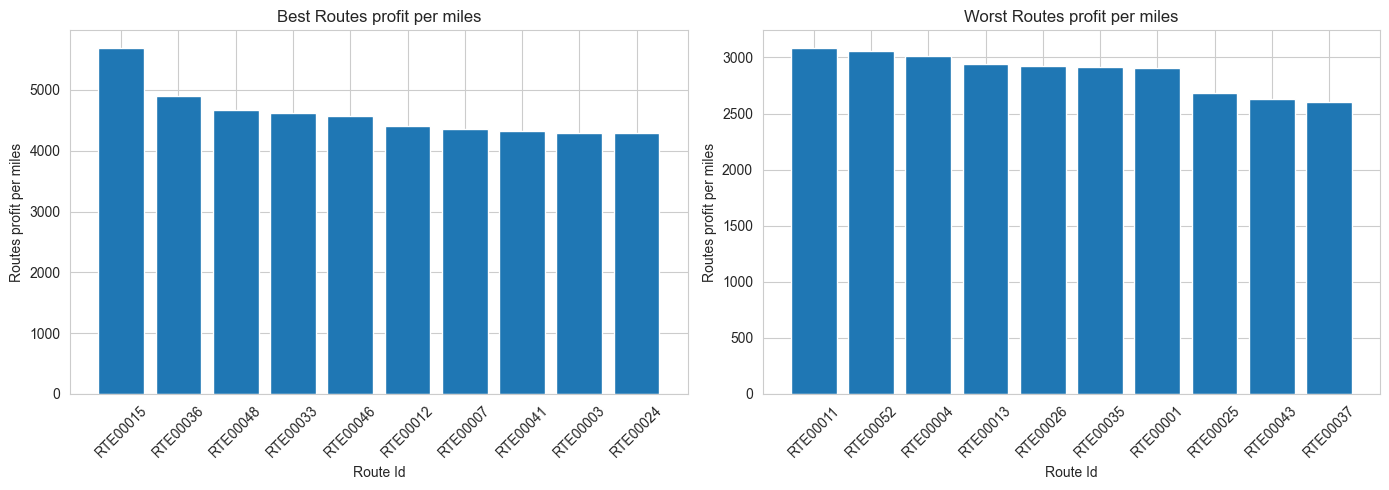

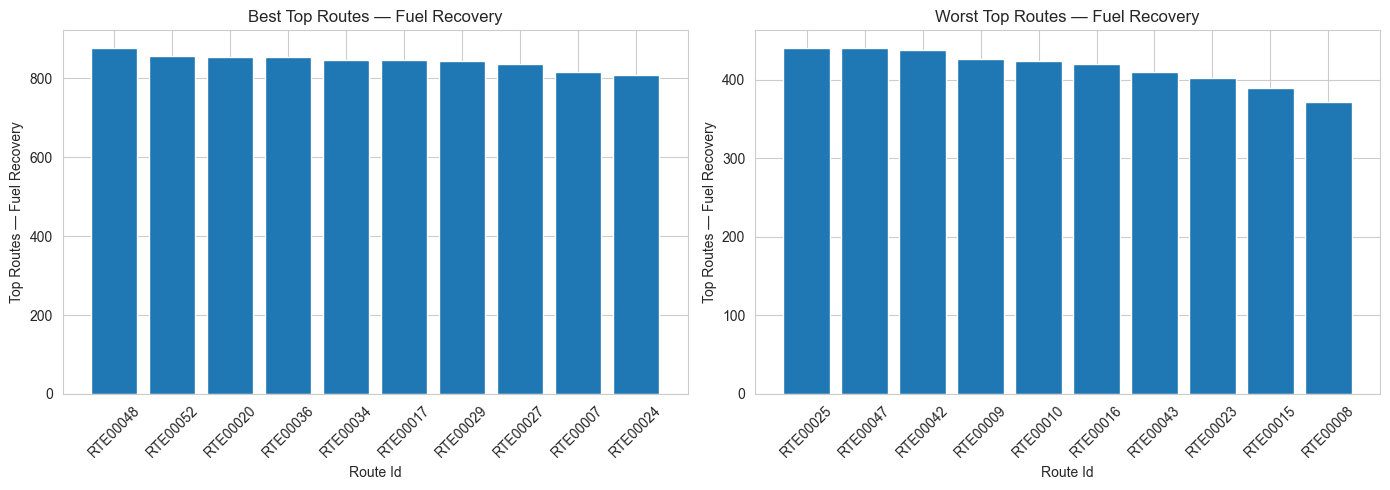

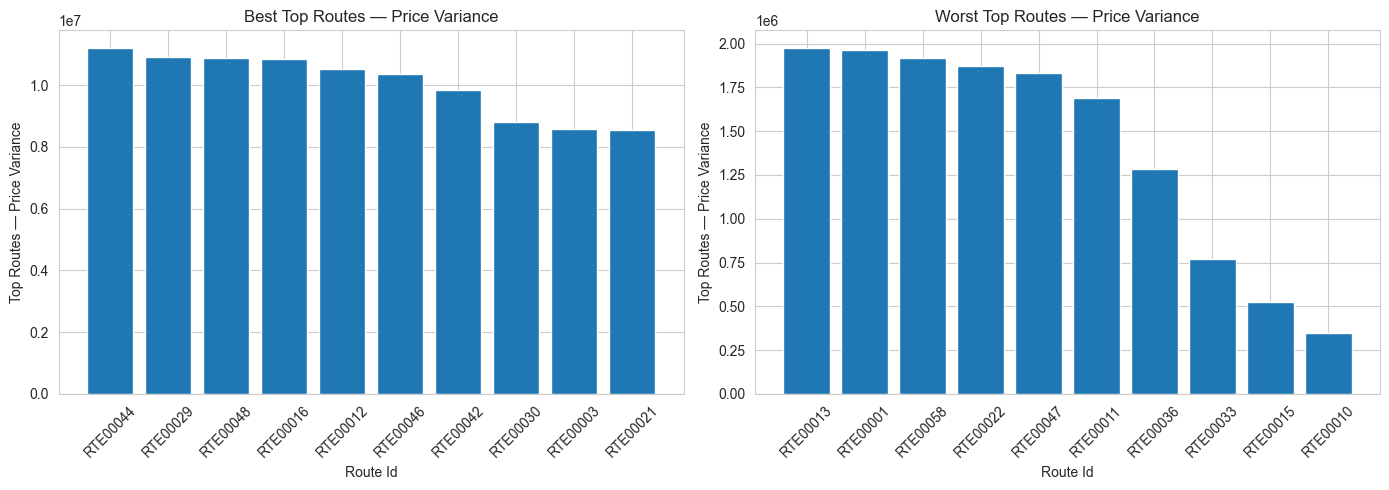

In [203]:
# Routes
plot_best_worst_entities(
    df=routes_profit_per_miles,
    id_col="route_id",
    metric_col='Total_profit_per_miles',
    title_prefix='Routes profit per miles',
    higher_is_better=True
)

#Total_Fuel_recovery_ratio
plot_best_worst_entities(
    df=routes_profit_per_miles,
    id_col="route_id",
    metric_col='Total_Fuel_recovery_ratio',
    title_prefix='Top Routes — Fuel Recovery',
    higher_is_better=True
)
#price_variance
plot_best_worst_entities(
    df=routes_profit_per_miles,
    id_col="route_id",
    metric_col='Total_price_variance',
    title_prefix='Top Routes — Price Variance',
    higher_is_better=True
)


C:\Users\amanc\AppData\Local\Temp\ipykernel_6076\332533790.py:4: UserWarning: The palette list has more values (3) than needed (1), which may not be intended.
  sns.countplot(


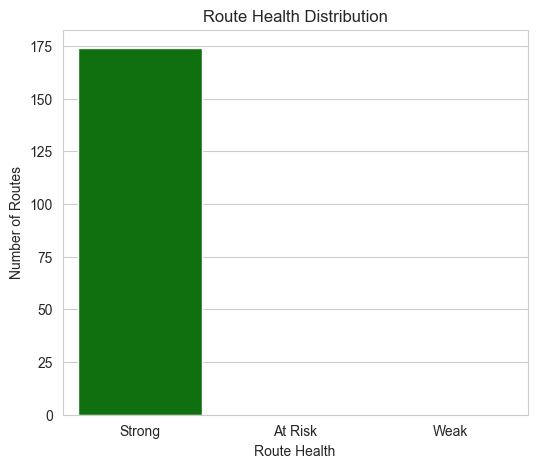

In [204]:
import  seaborn as sns
plt.figure(figsize=(6,5))

sns.countplot(
    data=routes_cost,
    x='route_health',
    order=['Strong', 'At Risk', 'Weak'],
    palette=['green', 'orange', 'red'],
    hue='route_health',
    legend=False
)

plt.title("Route Health Distribution")
plt.xlabel("Route Health")
plt.ylabel("Number of Routes")
plt.show()

**Fleet Utilization Analysis**


In [205]:
trucks_df.head()


,truck_id,unit_number,make,model_year,vin,acquisition_date,acquisition_mileage,fuel_type,tank_capacity_gallons,status,home_terminal
0,TRK00001,3463,Peterbilt,2016,1VV205190335317039,2017-04-27,18814,Diesel,200,Active,Omaha
1,TRK00002,6461,Kenworth,2015,1NV753749606229960,2018-10-04,26795,Diesel,150,Active,Seattle
2,TRK00003,2335,Peterbilt,2018,1NT803101860493229,2020-09-17,11795,Diesel,150,Maintenance,Atlanta
3,TRK00004,3317,Freightliner,2015,1VV131945381692351,2017-06-17,8875,Diesel,200,Active,Salt Lake City
4,TRK00005,6731,Freightliner,2016,1FT822215709701985,2021-10-08,42042,Diesel,250,Maintenance,Miami


In [206]:
truck_utilization_metrics_df.head()


,truck_id,month,trips_completed,total_miles,total_revenue,average_mpg,maintenance_events,maintenance_cost,downtime_hours,utilization_rate
0,TRK00001,2022-01-01,22,39269,84792.02,6.78,2,4380.98,63.10,0.71
1,TRK00001,2022-02-01,27,40787,88809.05,6.23,0,0.00,0.00,0.96
2,TRK00001,2022-03-01,34,57422,120453.71,6.49,0,0.00,0.00,1.10
3,TRK00001,2022-04-01,20,34428,73531.28,6.50,2,3548.15,71.80,0.67
4,TRK00001,2022-05-01,16,20851,40791.53,6.38,1,1969.42,43.90,0.52


In [207]:
truck_utilization_metrics_df_copy = truck_utilization_metrics_df.copy()
truck_utilization_metrics_df_copy['month'] = pd.to_datetime(truck_utilization_metrics_df_copy['month'],errors='coerce')
truck_utilization_metrics_df_copy['year'] = truck_utilization_metrics_df_copy['month'].dt.year

truck_groupby = truck_utilization_metrics_df_copy.groupby(['truck_id','year']).agg(
    sum_Total_trips =('trips_completed','sum'),
    sum_total_miles =('total_miles','sum'),
    sum_total_revenue = ('total_revenue','sum'),
    sum_maintenance_cost = ('maintenance_cost','sum'),
    Avg_downtime_hours = ('downtime_hours','mean'),
    Avg_utilization_rate = ('utilization_rate','mean')
).reset_index()

truck_groupby.head()

,truck_id,year,sum_Total_trips,sum_total_miles,sum_total_revenue,sum_maintenance_cost,Avg_downtime_hours,Avg_utilization_rate
0,TRK00001,2022,319,481239,1024755.98,17501.20,27.47,0.87
1,TRK00001,2023,315,441450,941116.80,21003.65,23.66,0.86
2,TRK00001,2024,317,433708,930465.39,13271.14,8.31,0.86
3,TRK00002,2022,304,427355,915640.07,17188.16,14.02,0.83
4,TRK00002,2023,292,412352,879009.31,21633.92,30.33,0.80


In [208]:

truck_performance = truck_groupby.merge(trucks_df['truck_id'],on='truck_id',how='left')
truck_performance.head()

,truck_id,year,sum_Total_trips,sum_total_miles,sum_total_revenue,sum_maintenance_cost,Avg_downtime_hours,Avg_utilization_rate
0,TRK00001,2022,319,481239,1024755.98,17501.20,27.47,0.87
1,TRK00001,2023,315,441450,941116.80,21003.65,23.66,0.86
2,TRK00001,2024,317,433708,930465.39,13271.14,8.31,0.86
3,TRK00002,2022,304,427355,915640.07,17188.16,14.02,0.83
4,TRK00002,2023,292,412352,879009.31,21633.92,30.33,0.80


In [209]:

trips_df_truck_copy = trips_df.copy()
trips_df_truck_copy['dispatch_date'] = pd.to_datetime(trips_df_truck_copy['dispatch_date'],errors='coerce')
trips_df_truck_copy['year'] =  trips_df_truck_copy['dispatch_date'].dt.year
trips_df_truck_copy.head()

,trip_id,load_id,driver_id,truck_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status,year
0,TRIP00000001,LOAD00000001,DRV00117,TRK00035,TRL00167,2022-01-01,1314,26.20,183.80,7.15,3.50,Completed,2022
1,TRIP00000002,LOAD00000002,DRV00141,TRK00108,TRL00082,2022-01-01,515,8.60,93.60,5.50,8.30,Completed,2022
2,TRIP00000003,LOAD00000003,DRV00032,TRK00031,TRL00138,2022-01-01,2509,45.00,339.10,7.40,12.00,Completed,2022
3,TRIP00000004,LOAD00000004,DRV00083,TRK00105,TRL00018,2022-01-01,717,11.10,110.30,6.50,9.60,Completed,2022
4,TRIP00000005,LOAD00000005,DRV00044,TRK00076,TRL00054,2022-01-01,2243,35.00,328.90,6.82,11.60,Completed,2022


In [210]:

truck_fuel_gallons = trips_df_truck_copy.groupby(['truck_id','year']).agg(
    sum_actual_duration_hours = ('actual_duration_hours','sum'),
    sum_fuel_gallons_used = ('fuel_gallons_used','sum')
).reset_index()
truck_fuel_gallons.head()

,truck_id,year,sum_actual_duration_hours,sum_fuel_gallons_used
0,TRK00001,2022,8435.40,75424.00
1,TRK00001,2023,7741.60,68962.10
2,TRK00001,2024,7617.20,66376.10
3,TRK00002,2022,7513.60,66287.50
4,TRK00002,2023,7229.00,64439.70


In [211]:

truck_performance_tab = truck_performance.merge(truck_fuel_gallons,on=['truck_id','year'],how='left')
truck_performance_tab.head()

,truck_id,year,sum_Total_trips,sum_total_miles,sum_total_revenue,sum_maintenance_cost,Avg_downtime_hours,Avg_utilization_rate,sum_actual_duration_hours,sum_fuel_gallons_used
0,TRK00001,2022,319,481239,1024755.98,17501.20,27.47,0.87,8435.40,75424.00
1,TRK00001,2023,315,441450,941116.80,21003.65,23.66,0.86,7741.60,68962.10
2,TRK00001,2024,317,433708,930465.39,13271.14,8.31,0.86,7617.20,66376.10
3,TRK00002,2022,304,427355,915640.07,17188.16,14.02,0.83,7513.60,66287.50
4,TRK00002,2023,292,412352,879009.31,21633.92,30.33,0.80,7229.00,64439.70


In [212]:

truck_performance_tab.columns.to_list()

['truck_id',
 'year',
 'sum_Total_trips',
 'sum_total_miles',
 'sum_total_revenue',
 'sum_maintenance_cost',
 'Avg_downtime_hours',
 'Avg_utilization_rate',
 'sum_actual_duration_hours',
 'sum_fuel_gallons_used']

In [213]:
#A) miles per trip
truck_performance_tab['miles_per_trip'] = truck_performance_tab['sum_total_miles']/truck_performance_tab['sum_Total_trips']
#B) MPG (Fleet Fuel Efficiency)
truck_performance_tab['MPG'] = truck_performance_tab['sum_total_miles']/truck_performance_tab['sum_fuel_gallons_used']
#C) Fuel cost per mile
truck_performance_tab['fuel_cost'] = truck_performance_tab['sum_fuel_gallons_used'] * avg_fuel_price
truck_performance_tab['fuel_cost_per_miles'] = truck_performance_tab['fuel_cost']/truck_performance_tab['sum_fuel_gallons_used']
#D) Hours per trip
truck_performance_tab['hours_per_trips'] = truck_performance_tab['sum_total_miles']/truck_performance_tab['sum_Total_trips']
#E) Revenue per mile
truck_performance_tab['revenue_per_miles'] = truck_performance_tab['sum_total_revenue']/truck_performance_tab['sum_total_miles']
#2. Fleet Profitability Metrics
#A) Maintenance cost per mile
truck_performance_tab['Maintenance_per_miles'] = truck_performance_tab['sum_maintenance_cost']/truck_performance_tab['sum_total_miles']
#B) Operating cost = Fuel cost + maintenance cost
truck_performance_tab['operating_cost'] = truck_performance_tab['fuel_cost'] + truck_performance_tab['sum_maintenance_cost']
#C) Operating cost per mile
truck_performance_tab['operating_cost_per_miles'] = truck_performance_tab['operating_cost']/truck_performance_tab['sum_total_miles']
#D) Profit per mile
truck_performance_tab['profit_per_mile'] = truck_performance_tab['revenue_per_miles'] - truck_performance_tab['operating_cost_per_miles']
#E) Total profit per truck
truck_performance_tab['total_profit'] = truck_performance_tab['sum_total_revenue'] - truck_performance_tab['operating_cost']
#3. Fleet Reliability Metrics
truck_performance_tab['down_time_rate'] = truck_performance_tab['Avg_downtime_hours']/truck_performance_tab['sum_total_miles']
#B) Availability%
truck_performance_tab['availability_pct'] = (
    1 - (truck_performance_tab['Avg_downtime_hours'] / 720)
) * 100
# C) Trips per downtime hour
truck_performance_tab['trips_per_downtime_hr'] = (
    truck_performance_tab['sum_Total_trips'] / truck_performance_tab['Avg_downtime_hours']
)

truck_performance_tab.head()


,truck_id,year,sum_Total_trips,sum_total_miles,sum_total_revenue,sum_maintenance_cost,Avg_downtime_hours,Avg_utilization_rate,sum_actual_duration_hours,sum_fuel_gallons_used,...,hours_per_trips,revenue_per_miles,Maintenance_per_miles,operating_cost,operating_cost_per_miles,profit_per_mile,total_profit,down_time_rate,availability_pct,trips_per_downtime_hr
0,TRK00001,2022,319,481239,1024755.98,17501.20,27.47,0.87,8435.40,75424.00,...,1508.59,2.13,0.04,311535.49,0.65,1.48,713220.49,0.00,96.19,11.61
1,TRK00001,2023,315,441450,941116.80,21003.65,23.66,0.86,7741.60,68962.10,...,1401.43,2.13,0.05,289846.75,0.66,1.48,651270.05,0.00,96.71,13.31
2,TRK00001,2024,317,433708,930465.39,13271.14,8.31,0.86,7617.20,66376.10,...,1368.16,2.15,0.03,272032.93,0.63,1.52,658432.46,0.00,98.85,38.15
3,TRK00002,2022,304,427355,915640.07,17188.16,14.02,0.83,7513.60,66287.50,...,1405.77,2.14,0.04,275604.55,0.64,1.50,640035.52,0.00,98.05,21.69
4,TRK00002,2023,292,412352,879009.31,21633.92,30.33,0.80,7229.00,64439.70,...,1412.16,2.13,0.05,272846.82,0.66,1.47,606162.49,0.00,95.79,9.63


In [214]:
truck_performance_tab_copy = truck_performance_tab.copy()
# 2) call the robust pivot + YoY function
# Note: value_col is your revenue column name: 'sum_total_revenue'
trend_df = calc_yoy_growth_dynamic_safe(
    truck_performance_tab_copy,
    id_col="truck_id",
    year_col="year",
    value_col="sum_total_revenue"
)

# 3) classify trends with default thresholds (change thresholds if needed)
trend_df_classified_truck = classify_trend_safe(
    trend_df,
    id_col="truck_id",
    pos_threshold=5.0,    # +5% defines "strong positive"
    neg_threshold=-5.0,   # -5% defines "strong negative"
    stable_abs=5.0        # within ±5% considered "stable"
)
# 4) inspect result
display(trend_df_classified_truck.head(10))

trend_df_classified_truck.to_csv('../Data/processed/trend_df_classified_truck.csv', index=False)
print("Output columns:", trend_df_classified_truck.columns.tolist())

__year_val,truck_id,rev_2022,rev_2023,rev_2024,yoy_2022_2023,yoy_2023_2024,cagr_2022_2024,trend_label
0,TRK00001,1024755.98,941116.80,930465.39,-8.16,-1.13,-4.71,Volatile
1,TRK00002,915640.07,879009.31,917712.48,-4.00,4.40,0.11,Stable
2,TRK00004,1019800.20,920188.32,863613.61,-9.77,-6.15,-7.98,Declining
3,TRK00006,848000.97,972121.57,958424.01,14.64,-1.41,6.31,Upward
4,TRK00007,948952.29,1009339.78,929456.10,6.36,-7.91,-1.03,Declining
5,TRK00008,887906.51,984483.62,908198.89,10.88,-7.75,1.14,Declining
6,TRK00009,931124.33,883307.33,1018493.17,-5.14,15.30,4.59,Strong Upward
7,TRK00010,890243.60,853807.84,1033896.71,-4.09,21.09,7.77,Strong Upward
8,TRK00011,974920.80,915519.75,923603.57,-6.09,0.88,-2.67,Volatile
9,TRK00012,948139.00,961713.04,974313.78,1.43,1.31,1.37,Stable


Output columns: ['truck_id', 'rev_2022', 'rev_2023', 'rev_2024', 'yoy_2022_2023', 'yoy_2023_2024', 'cagr_2022_2024', 'trend_label']


In [215]:
# ================= 4️⃣ FLEET SCORECARD (RANKING) ==================

from sklearn.preprocessing import MinMaxScaler

score_df = truck_performance_tab_copy.copy()

# Metrics where higher = better
pos_cols = ['MPG','revenue_per_miles','profit_per_mile','availability_pct']

# Metrics where lower = better (invert them)
neg_cols = ['fuel_cost_per_miles','Maintenance_per_miles','down_time_rate']

scaler = MinMaxScaler()

# Normalize positive metrics
score_df[pos_cols] = scaler.fit_transform(score_df[pos_cols])

# Normalize negative metrics (invert)
score_df[neg_cols] = 1 - scaler.fit_transform(score_df[neg_cols])

# Final weighted score
score_df['fleet_score'] = (
    score_df['MPG']*0.20 +
    score_df['revenue_per_miles']*0.20 +
    score_df['profit_per_mile']*0.25 +
    score_df['availability_pct']*0.15 +
    score_df['fuel_cost_per_miles']*0.10 +
    score_df['Maintenance_per_miles']*0.10
)

score_df["truck_score_100"] = score_df["fleet_score"] * 100
score_df["rank"] = score_df["truck_score_100"].rank(ascending=False).astype(int)


leaderboard_truck = score_df.sort_values("rank")[[
    "rank",
    "truck_id",
    "truck_score_100",

]]

display(leaderboard_truck)
leaderboard_truck.to_csv('../Data/processed/truck_leaderboard.csv', index=False)



,rank,truck_id,truck_score_100
47,1,TRK00019,84.01
87,2,TRK00040,83.03
107,3,TRK00049,81.64
154,4,TRK00067,81.16
75,5,TRK00035,81.10
...,...,...,...
185,272,TRK00079,34.37
62,273,TRK00026,33.47
175,274,TRK00074,32.53
124,275,TRK00055,29.23


**Maintenance Cost & Downtime Analysis**

In [216]:
maintenance_col =['truck_id','year','Maintenance_per_miles','sum_maintenance_cost','sum_total_miles','Avg_downtime_hours', 'availability_pct','down_time_rate', 'total_profit']
maintenance_tab = truck_performance_tab_copy[maintenance_col].copy()
maintenance_tab.head()

,truck_id,year,Maintenance_per_miles,sum_maintenance_cost,sum_total_miles,Avg_downtime_hours,availability_pct,down_time_rate,total_profit
0,TRK00001,2022,0.04,17501.20,481239,27.47,96.19,0.00,713220.49
1,TRK00001,2023,0.05,21003.65,441450,23.66,96.71,0.00,651270.05
2,TRK00001,2024,0.03,13271.14,433708,8.31,98.85,0.00,658432.46
3,TRK00002,2022,0.04,17188.16,427355,14.02,98.05,0.00,640035.52
4,TRK00002,2023,0.05,21633.92,412352,30.33,95.79,0.00,606162.49


In [217]:
def classify_maintenance_health(row):

    if (row['Maintenance_per_miles'] > maintenance_tab['Maintenance_per_miles'].quantile(0.75)) \
       or (row['down_time_rate'] > maintenance_tab['down_time_rate'].quantile(0.75)):
        return 'Critical'

    elif row['Maintenance_per_miles'] > maintenance_tab['Maintenance_per_miles'].median():
        return 'Watchlist'

    else:
        return 'Healthy'

maintenance_tab['maintenance_health'] = maintenance_tab.apply(
    classify_maintenance_health,
    axis=1
)

In [218]:
maintenance_tab['maintenance_health'].value_counts()

maintenance_health
Healthy      132
Critical      91
Watchlist     53
Name: count, dtype: int64

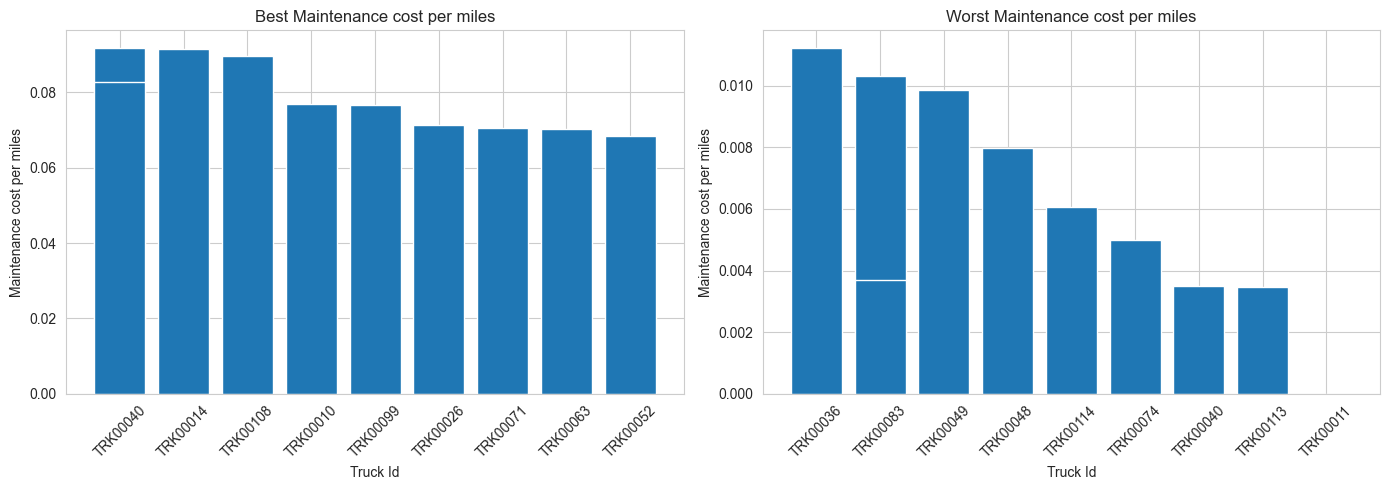

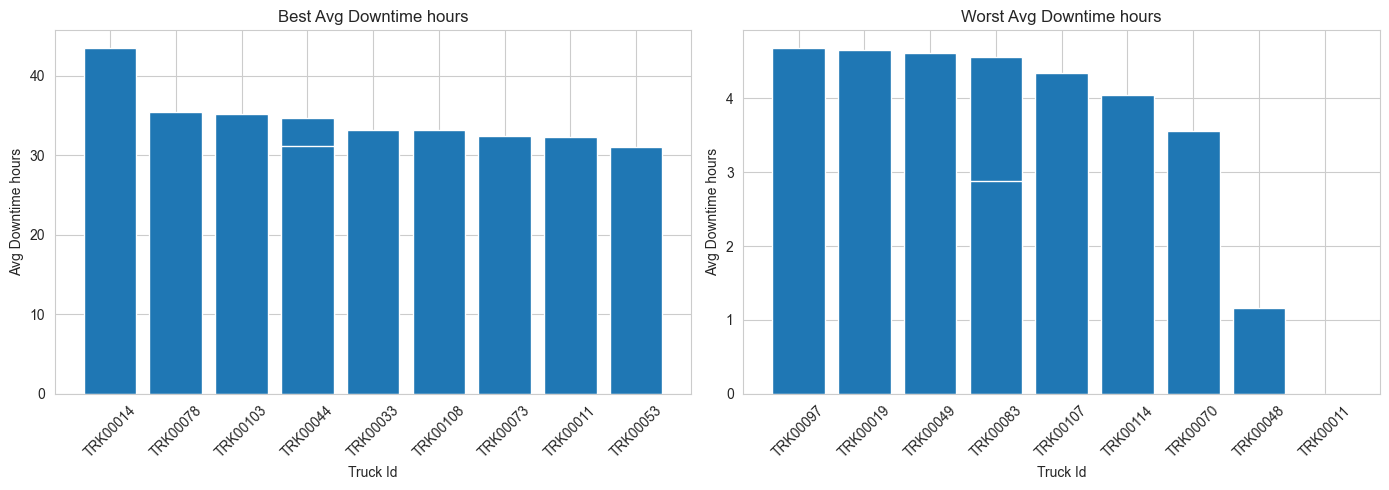

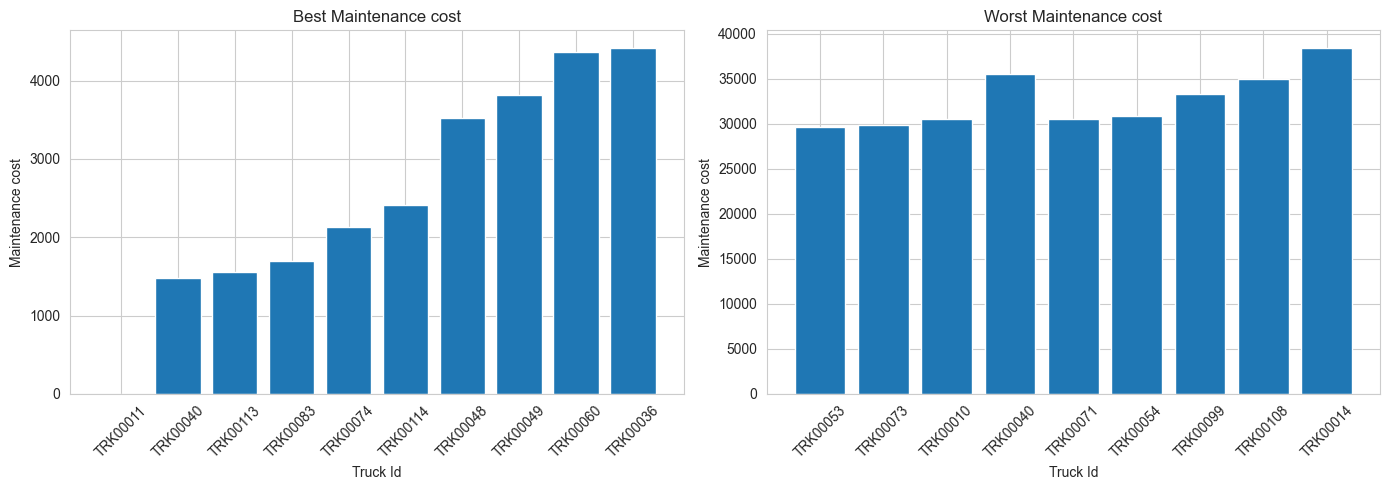

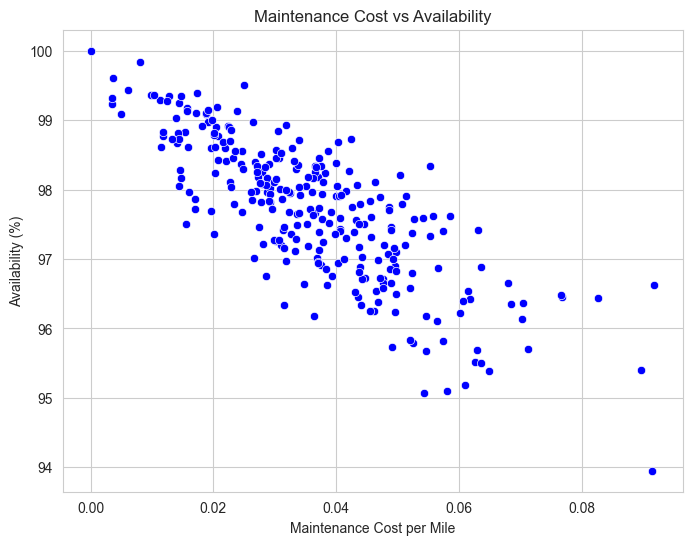

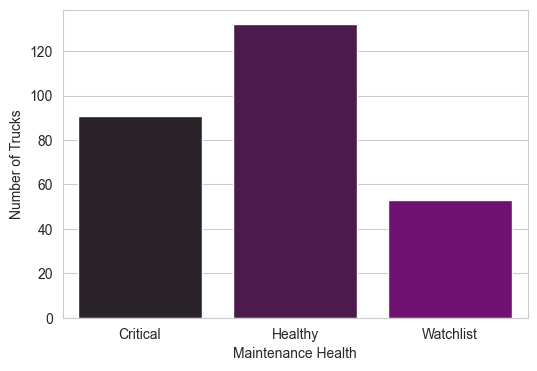

In [219]:
#Maintenance_cost_per_miles
plot_best_worst_entities(
    df= maintenance_tab,
    id_col="truck_id",
    metric_col='Maintenance_per_miles',
    title_prefix='Maintenance cost per miles',
    higher_is_better=True
)

#Avg Downtime hours
plot_best_worst_entities(
    df= maintenance_tab,
    id_col="truck_id",
    metric_col='Avg_downtime_hours',
    title_prefix='Avg Downtime hours',
    higher_is_better=True
)

#Total Maintenance cost
plot_best_worst_entities(
    df= maintenance_tab,
    id_col="truck_id",
    metric_col='sum_maintenance_cost',
    title_prefix='Maintenance cost',
    higher_is_better=False
)

#Maintenance Cost vs Availability
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=maintenance_tab,
    x='Maintenance_per_miles',
    y='availability_pct',
    color='blue'
)

plt.title("Maintenance Cost vs Availability")
plt.xlabel("Maintenance Cost per Mile")
plt.ylabel("Availability (%)")
plt.show()


#Maintenance Health Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    data=maintenance_tab,
    x='maintenance_health',
    palette='dark:purple',
    hue='maintenance_health',
    legend=False
)

plt.title("")
plt.xlabel("Maintenance Health")
plt.ylabel("Number of Trucks")
plt.show()


**Fuel Efficiency Analysis**

In [220]:
fuel_temp =  trips_df.copy()
fuel_temp['dispatch_date'] = pd.to_datetime(fuel_temp['dispatch_date'],errors='coerce')
fuel_temp['year'] = fuel_temp['dispatch_date'].dt.year
fuel_tab = fuel_temp.groupby(['year']).agg(
    Total_distance_miles = ('actual_distance_miles','sum'),
    Total_time_hours = ('actual_duration_hours','sum'),
    Total_fuel_gallons_used = ('fuel_gallons_used','sum'),
).reset_index()
fuel_tab

,year,Total_distance_miles,Total_time_hours,Total_fuel_gallons_used
0,2022,40887271,715554.70,6344699.00
1,2023,40496933,707621.40,6283229.50
2,2024,40774997,713327.20,6318351.60


In [221]:

fuel_tab['MPG'] = fuel_tab['Total_distance_miles']/fuel_tab['Total_fuel_gallons_used']
fuel_tab['fuel_cost'] = fuel_tab['Total_fuel_gallons_used']*avg_fuel_price
fuel_tab

,year,Total_distance_miles,Total_time_hours,Total_fuel_gallons_used,MPG,fuel_cost
0,2022,40887271,715554.70,6344699.00,6.44,24734289.67
1,2023,40496933,707621.40,6283229.50,6.45,24494655.85
2,2024,40774997,713327.20,6318351.60,6.45,24631576.48


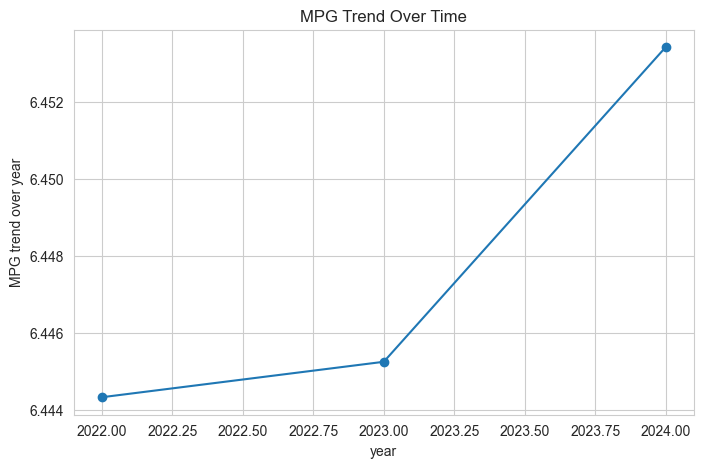

In [222]:
plt.figure(figsize=(8, 5)) # Optional: adjust figure size
plt.plot(fuel_tab['year'], fuel_tab['MPG'], marker='o', linestyle='-') # 'o' adds markers to data points, '-' connects them with lines

# Add titles and labels
plt.title('MPG Trend Over Time')
plt.xlabel('year')
plt.ylabel('MPG trend over year')
plt.grid(True) # Optional: add a grid for better readability

# Display the graph
plt.show()

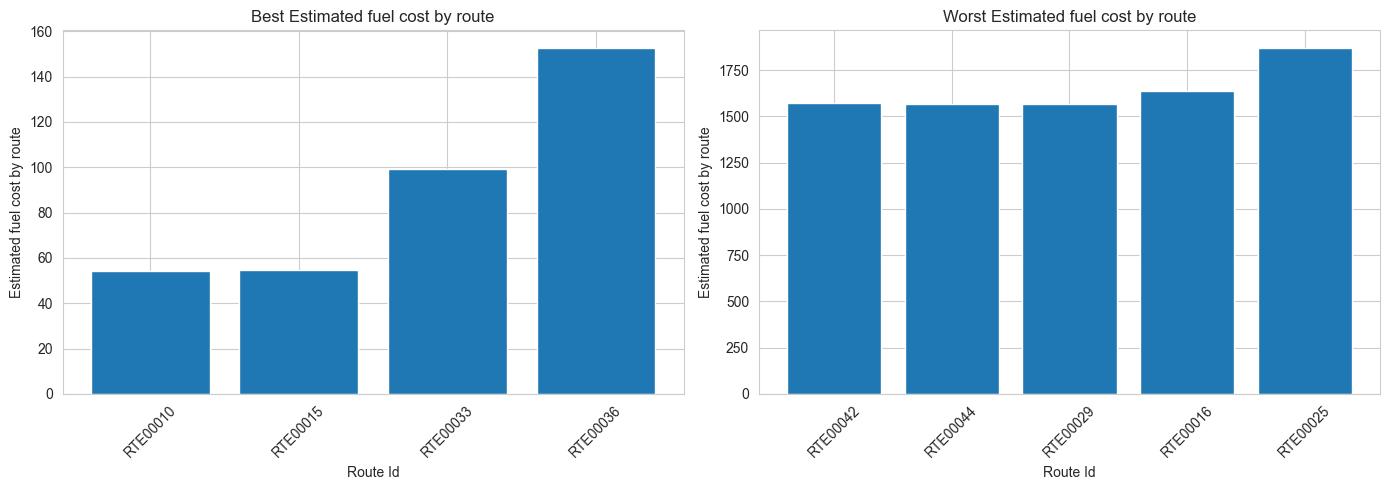

In [223]:
plot_best_worst_entities(
    df=routes_cost,
    id_col="route_id",
    metric_col='Estimated_fuel_cost',
    title_prefix='Estimated fuel cost by route',
    higher_is_better=False
)

**Customer Revenue & Service Analysis**

In [224]:

customers_df['contract_start_date'] = pd.to_datetime(customers_df['contract_start_date'],errors='coerce')
customers_df['year'] = customers_df['contract_start_date'].dt.year
customers_df.head()


,customer_id,customer_name,customer_type,credit_terms_days,primary_freight_type,account_status,contract_start_date,annual_revenue_potential,year
0,CUST00001,Metro Wholesale,Dedicated,60,General,Inactive,2020-02-20,985117,2020
1,CUST00002,National Retail,Contract,30,Retail,Active,2021-06-02,4936566,2021
2,CUST00003,XYZ Industries,Contract,30,Consumer Goods,Active,2020-09-04,3102814,2020
3,CUST00004,American Corp,Contract,15,Food/Beverage,Active,2020-11-29,3948027,2020
4,CUST00005,American Distribution,Spot,45,Consumer Goods,Active,2020-02-04,3682564,2020


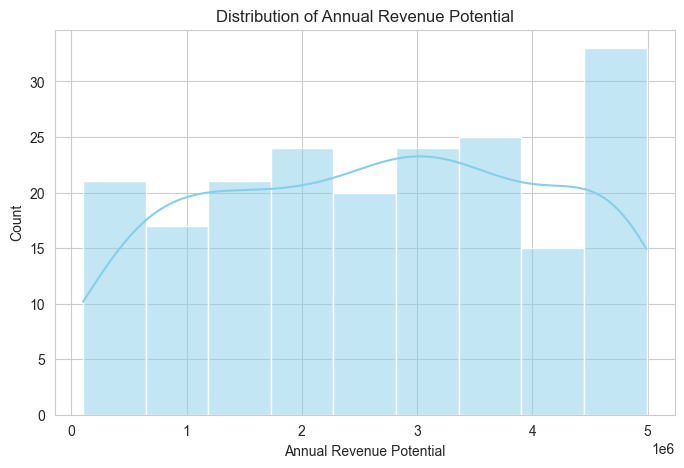

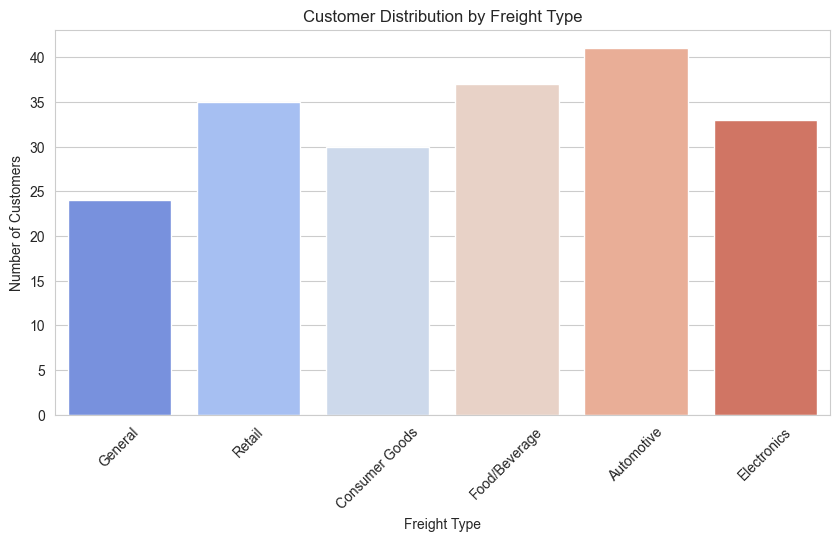

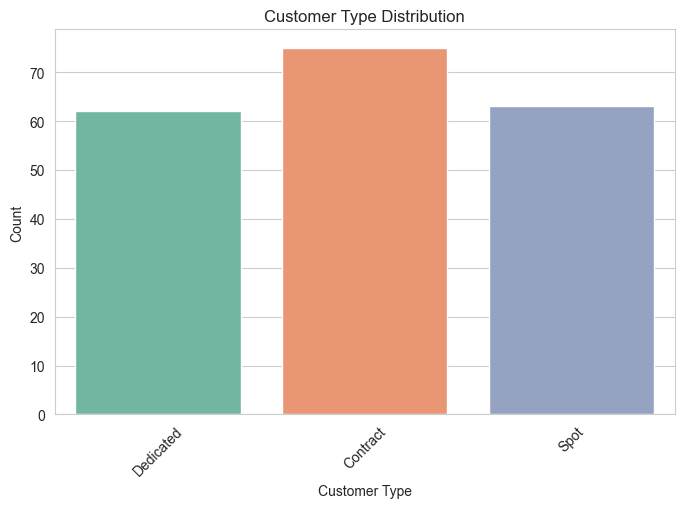

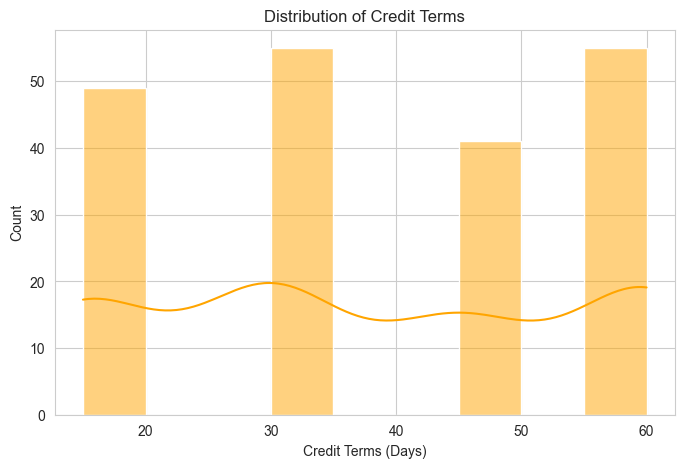

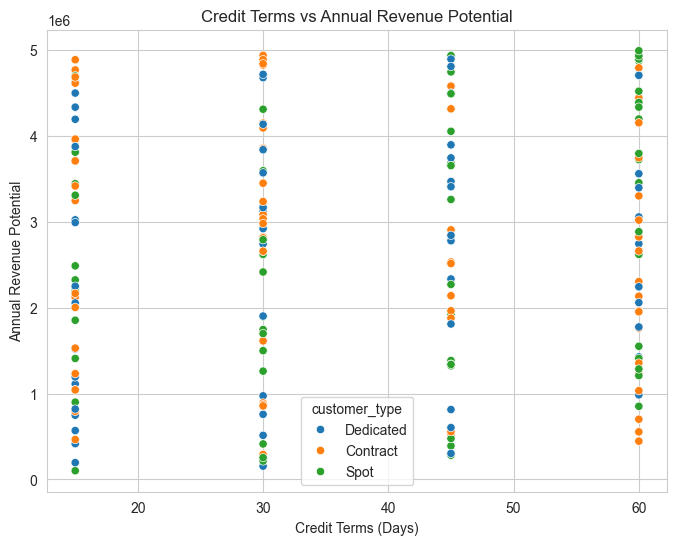

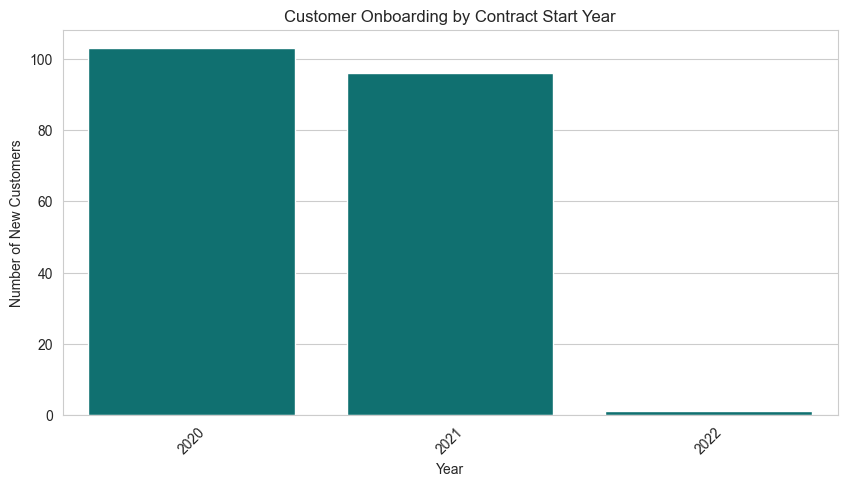

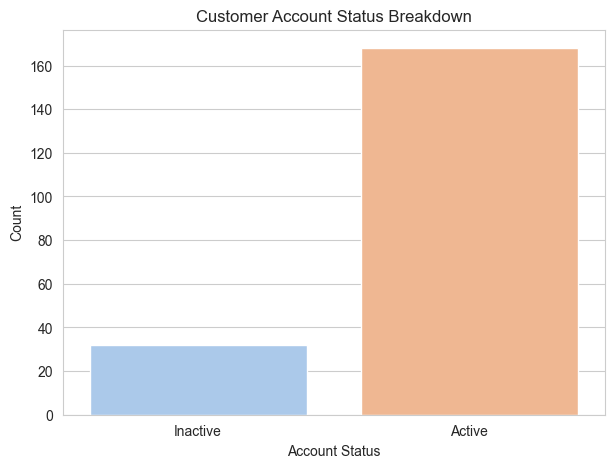

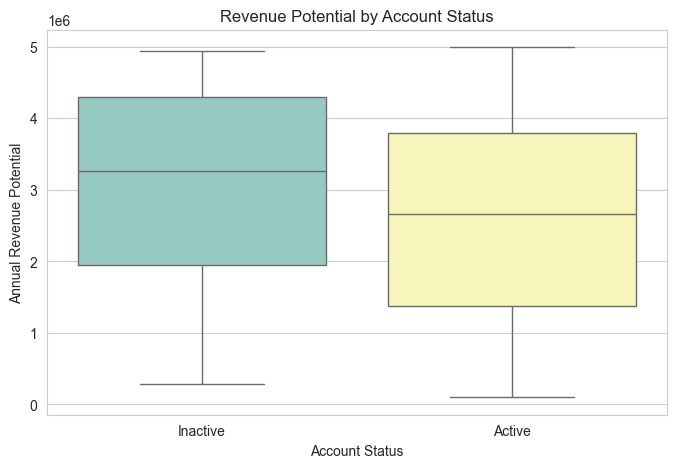

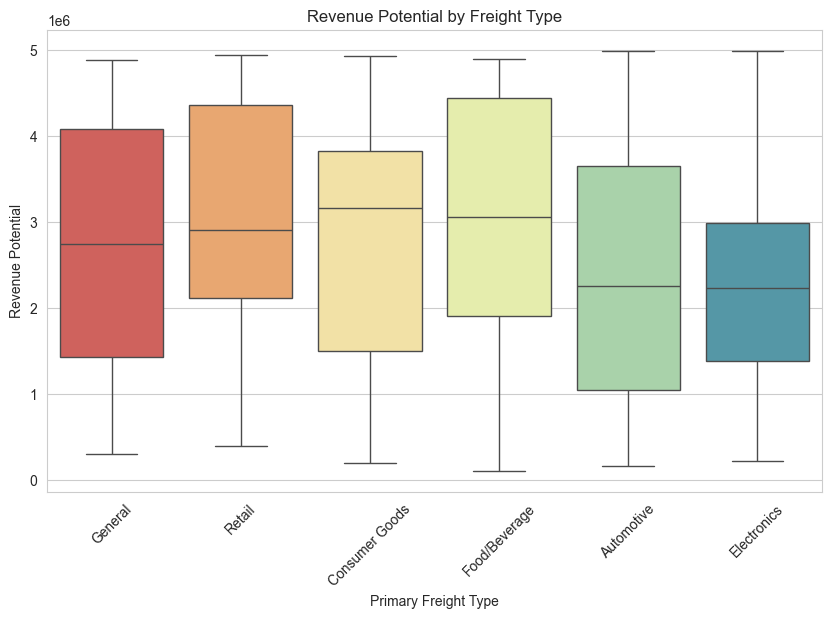

In [225]:
#Distribution of Annual Revenue Potential
sns.set_style('whitegrid')
plt.figure(figsize=(8,5))
sns.histplot(customers_df['annual_revenue_potential'], kde=True, color='skyblue')
plt.title("Distribution of Annual Revenue Potential")
plt.xlabel("Annual Revenue Potential")
plt.ylabel("Count")
plt.show()

#Customer Distribution by Freight Type
plt.figure(figsize=(10,5))
sns.countplot(data=customers_df, x='primary_freight_type', palette='coolwarm',hue='primary_freight_type',legend=False)
plt.title("Customer Distribution by Freight Type")
plt.xlabel("Freight Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

#Customer Type Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=customers_df, x='customer_type', palette='Set2', hue='customer_type',legend=False)
plt.title("Customer Type Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#Distribution of Credit Terms
plt.figure(figsize=(8,5))
sns.histplot(customers_df['credit_terms_days'], kde=True, color='orange')
plt.title("Distribution of Credit Terms")
plt.xlabel("Credit Terms (Days)")
plt.ylabel("Count")
plt.show()

#Credit Terms vs Annual Revenue Potential
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=customers_df,
    x='credit_terms_days',
    y='annual_revenue_potential',
    hue='customer_type',
    palette='tab10'
)
plt.title("Credit Terms vs Annual Revenue Potential")
plt.xlabel("Credit Terms (Days)")
plt.ylabel("Annual Revenue Potential")
plt.show()

#Customer Onboarding by Contract Start Year
plt.figure(figsize=(10,5))
sns.countplot(data=customers_df, x='year', color='teal')
plt.title("Customer Onboarding by Contract Start Year")
plt.xlabel("Year")
plt.ylabel("Number of New Customers")
plt.xticks(rotation=45)
plt.show()

#Customer Account Status Breakdown
plt.figure(figsize=(7,5))
sns.countplot(data=customers_df, x='account_status', palette='pastel',hue='account_status', legend=False)
plt.title("Customer Account Status Breakdown")
plt.xlabel("Account Status")
plt.ylabel("Count")
plt.show()

#Revenue Potential by Account Status
plt.figure(figsize=(8,5))
sns.boxplot(data=customers_df, x='account_status', y='annual_revenue_potential', palette='Set3',hue ='account_status',legend=False)
plt.title("Revenue Potential by Account Status")
plt.xlabel("Account Status")
plt.ylabel("Annual Revenue Potential")
plt.show()

#Revenue Potential by Freight Type
plt.figure(figsize=(10,6))
sns.boxplot(data=customers_df, x='primary_freight_type', y='annual_revenue_potential', palette='Spectral',hue='primary_freight_type',legend=False)
plt.title("Revenue Potential by Freight Type")
plt.xlabel("Primary Freight Type")
plt.ylabel("Revenue Potential")
plt.xticks(rotation=45)
plt.show()


**Safety Metrics & Risk Analysis**

In [226]:
safety_incident_df.head()

,incident_id,trip_id,truck_id,driver_id,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,vehicle_damage_cost,cargo_damage_cost,claim_amount,preventable_flag,description
0,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,12629.26,0.00,12629.26,True,Severe incident involving equipment
1,INC00000002,TRIP00032462,TRK00084,DRV00006,2023-02-19 11:00:00,Moving Violation,Columbus,NC,False,False,2700.70,14284.24,16984.94,False,Severe incident involving weather
2,INC00000003,TRIP00067583,TRK00106,DRV00119,2024-05-20 01:00:00,Customer Complaint,Seattle,OK,True,False,24302.32,0.00,24302.32,True,Minor incident involving traffic
3,INC00000004,TRIP00049128,TRK00085,DRV00134,2023-09-26 03:00:00,Equipment Damage,Kansas City,TN,True,False,4879.13,0.00,4879.13,True,Moderate incident involving equipment
4,INC00000005,TRIP00062884,TRK00014,DRV00133,2024-03-20 14:00:00,DOT Violation,Las Vegas,IN,False,False,14951.40,0.00,14951.40,False,Minor incident involving other driver


In [227]:
safety_incident_df['incident_date'] = pd.to_datetime(safety_incident_df['incident_date'])
safety_incident_df['year'] = safety_incident_df['incident_date'].dt.year
safety_incident_df['month'] = safety_incident_df['incident_date'].dt.month
safety_incident_df['days'] = safety_incident_df['incident_date'].dt.day

In [228]:
safety_incident_df['Total_Damage_cost'] = safety_incident_df['vehicle_damage_cost'] + safety_incident_df['cargo_damage_cost']

In [229]:
safety_incident_df['severity_level'] = safety_incident_df['description'].str.split().str[0]
safety_incident_df['incident_cause'] = 'other'

safety_incident_df.loc[safety_incident_df['description'].str.contains('weather',case=False,na=False),'incident_cause'] = "Weather"
safety_incident_df.loc[safety_incident_df['description'].str.contains('traffic',case=False,na=False),'incident_cause'] = "Traffic"
safety_incident_df.loc[safety_incident_df['description'].str.contains('equipment',case=False,na=False),'incident_cause'] = "Equipment"
safety_incident_df.loc[safety_incident_df['description'].str.contains('other driver',case=False,na=False),'incident_cause'] = "Other_driver"

In [230]:
safety_incident_df.head()

,incident_id,trip_id,truck_id,driver_id,incident_date,incident_type,location_city,location_state,at_fault_flag,injury_flag,...,cargo_damage_cost,claim_amount,preventable_flag,description,year,month,days,Total_Damage_cost,severity_level,incident_cause
0,INC00000001,TRIP00036079,TRK00006,DRV00006,2023-04-09 14:00:00,Moving Violation,Columbus,PA,True,False,...,0.00,12629.26,True,Severe incident involving equipment,2023,4,9,12629.26,Severe,Equipment
1,INC00000002,TRIP00032462,TRK00084,DRV00006,2023-02-19 11:00:00,Moving Violation,Columbus,NC,False,False,...,14284.24,16984.94,False,Severe incident involving weather,2023,2,19,16984.94,Severe,Weather
2,INC00000003,TRIP00067583,TRK00106,DRV00119,2024-05-20 01:00:00,Customer Complaint,Seattle,OK,True,False,...,0.00,24302.32,True,Minor incident involving traffic,2024,5,20,24302.32,Minor,Traffic
3,INC00000004,TRIP00049128,TRK00085,DRV00134,2023-09-26 03:00:00,Equipment Damage,Kansas City,TN,True,False,...,0.00,4879.13,True,Moderate incident involving equipment,2023,9,26,4879.13,Moderate,Equipment
4,INC00000005,TRIP00062884,TRK00014,DRV00133,2024-03-20 14:00:00,DOT Violation,Las Vegas,IN,False,False,...,0.00,14951.40,False,Minor incident involving other driver,2024,3,20,14951.40,Minor,Other_driver


In [231]:
perventable_incident = safety_incident_df.groupby(['preventable_flag']).agg(
    Total_incident = ('incident_id','count'),
    Total_damage_cost_sum = ('Total_Damage_cost','sum'),
    Total_claim_cost_sum = ('claim_amount','sum'),

).reset_index()
perventable_incident.head()

,preventable_flag,Total_incident,Total_damage_cost_sum,Total_claim_cost_sum
0,False,106,1748695.86,1748695.86
1,True,64,904475.96,904475.96


In [232]:
incident_tab = safety_incident_df.groupby(['incident_cause']).agg(
    Total_incident=('incident_id', 'count'),
    Total_damage_cost_sum=('Total_Damage_cost', 'sum'),
    Total_claim_cost_sum=('claim_amount', 'sum'),

).reset_index()
incident_tab.head()

,incident_cause,Total_incident,Total_damage_cost_sum,Total_claim_cost_sum
0,Equipment,43,856915.74,856915.74
1,Other_driver,40,663729.53,663729.53
2,Traffic,41,535009.23,535009.23
3,Weather,46,597517.32,597517.32


In [233]:
driver_safety_summary = safety_incident_df.groupby('driver_id').agg(
        total_incidents=('incident_id', 'count'),
        preventable_incidents=('preventable_flag', 'sum'),
        at_fault_incidents=('at_fault_flag', 'sum'),
        total_damage_cost=('Total_Damage_cost', 'sum'),
        avg_damage_per_incident=('Total_Damage_cost', 'mean'),
        severe_incidents=('severity_level', lambda x: (x == 'Severe').sum())
    ).reset_index()


driver_safety_summary['preventable_rate'] = driver_safety_summary['preventable_incidents'] / driver_safety_summary['total_incidents']
driver_safety_summary['at_fault_rate'] = driver_safety_summary['at_fault_incidents'] / driver_safety_summary['total_incidents']
driver_safety_summary.head()

,driver_id,total_incidents,preventable_incidents,at_fault_incidents,total_damage_cost,avg_damage_per_incident,severe_incidents,preventable_rate,at_fault_rate
0,DRV00001,1,0,1,22667.73,22667.73,1,0.00,1.00
1,DRV00002,2,1,0,55799.08,27899.54,0,0.50,0.00
2,DRV00003,6,2,1,48700.26,8116.71,1,0.33,0.17
3,DRV00004,2,0,1,10006.92,5003.46,0,0.00,0.50
4,DRV00005,2,0,0,6524.27,3262.14,0,0.00,0.00


In [234]:
truck_safety_summary = safety_incident_df.groupby('truck_id').agg(
        total_incidents=('incident_id', 'count'),
        preventable_incidents=('preventable_flag', 'sum'),
        at_fault_incidents=('at_fault_flag', 'sum'),
        total_damage_cost=('Total_Damage_cost', 'sum'),
        avg_damage_per_incident=('Total_Damage_cost', 'mean'),
        severe_incidents=('severity_level', lambda x: (x == 'Severe').sum())
    ).reset_index()

truck_safety_summary['preventable_rate'] = truck_safety_summary['preventable_incidents'] / truck_safety_summary['total_incidents']
truck_safety_summary['at_fault_rate'] = truck_safety_summary['at_fault_incidents'] / truck_safety_summary['total_incidents']
truck_safety_summary.head()

,truck_id,total_incidents,preventable_incidents,at_fault_incidents,total_damage_cost,avg_damage_per_incident,severe_incidents,preventable_rate,at_fault_rate
0,TRK00001,2,1,1,7737.05,3868.53,0,0.50,0.50
1,TRK00002,3,2,2,124989.41,41663.14,1,0.67,0.67
2,TRK00004,2,0,0,22088.26,11044.13,0,0.00,0.00
3,TRK00006,2,2,2,30413.02,15206.51,2,1.00,1.00
4,TRK00007,6,5,2,67763.96,11293.99,3,0.83,0.33


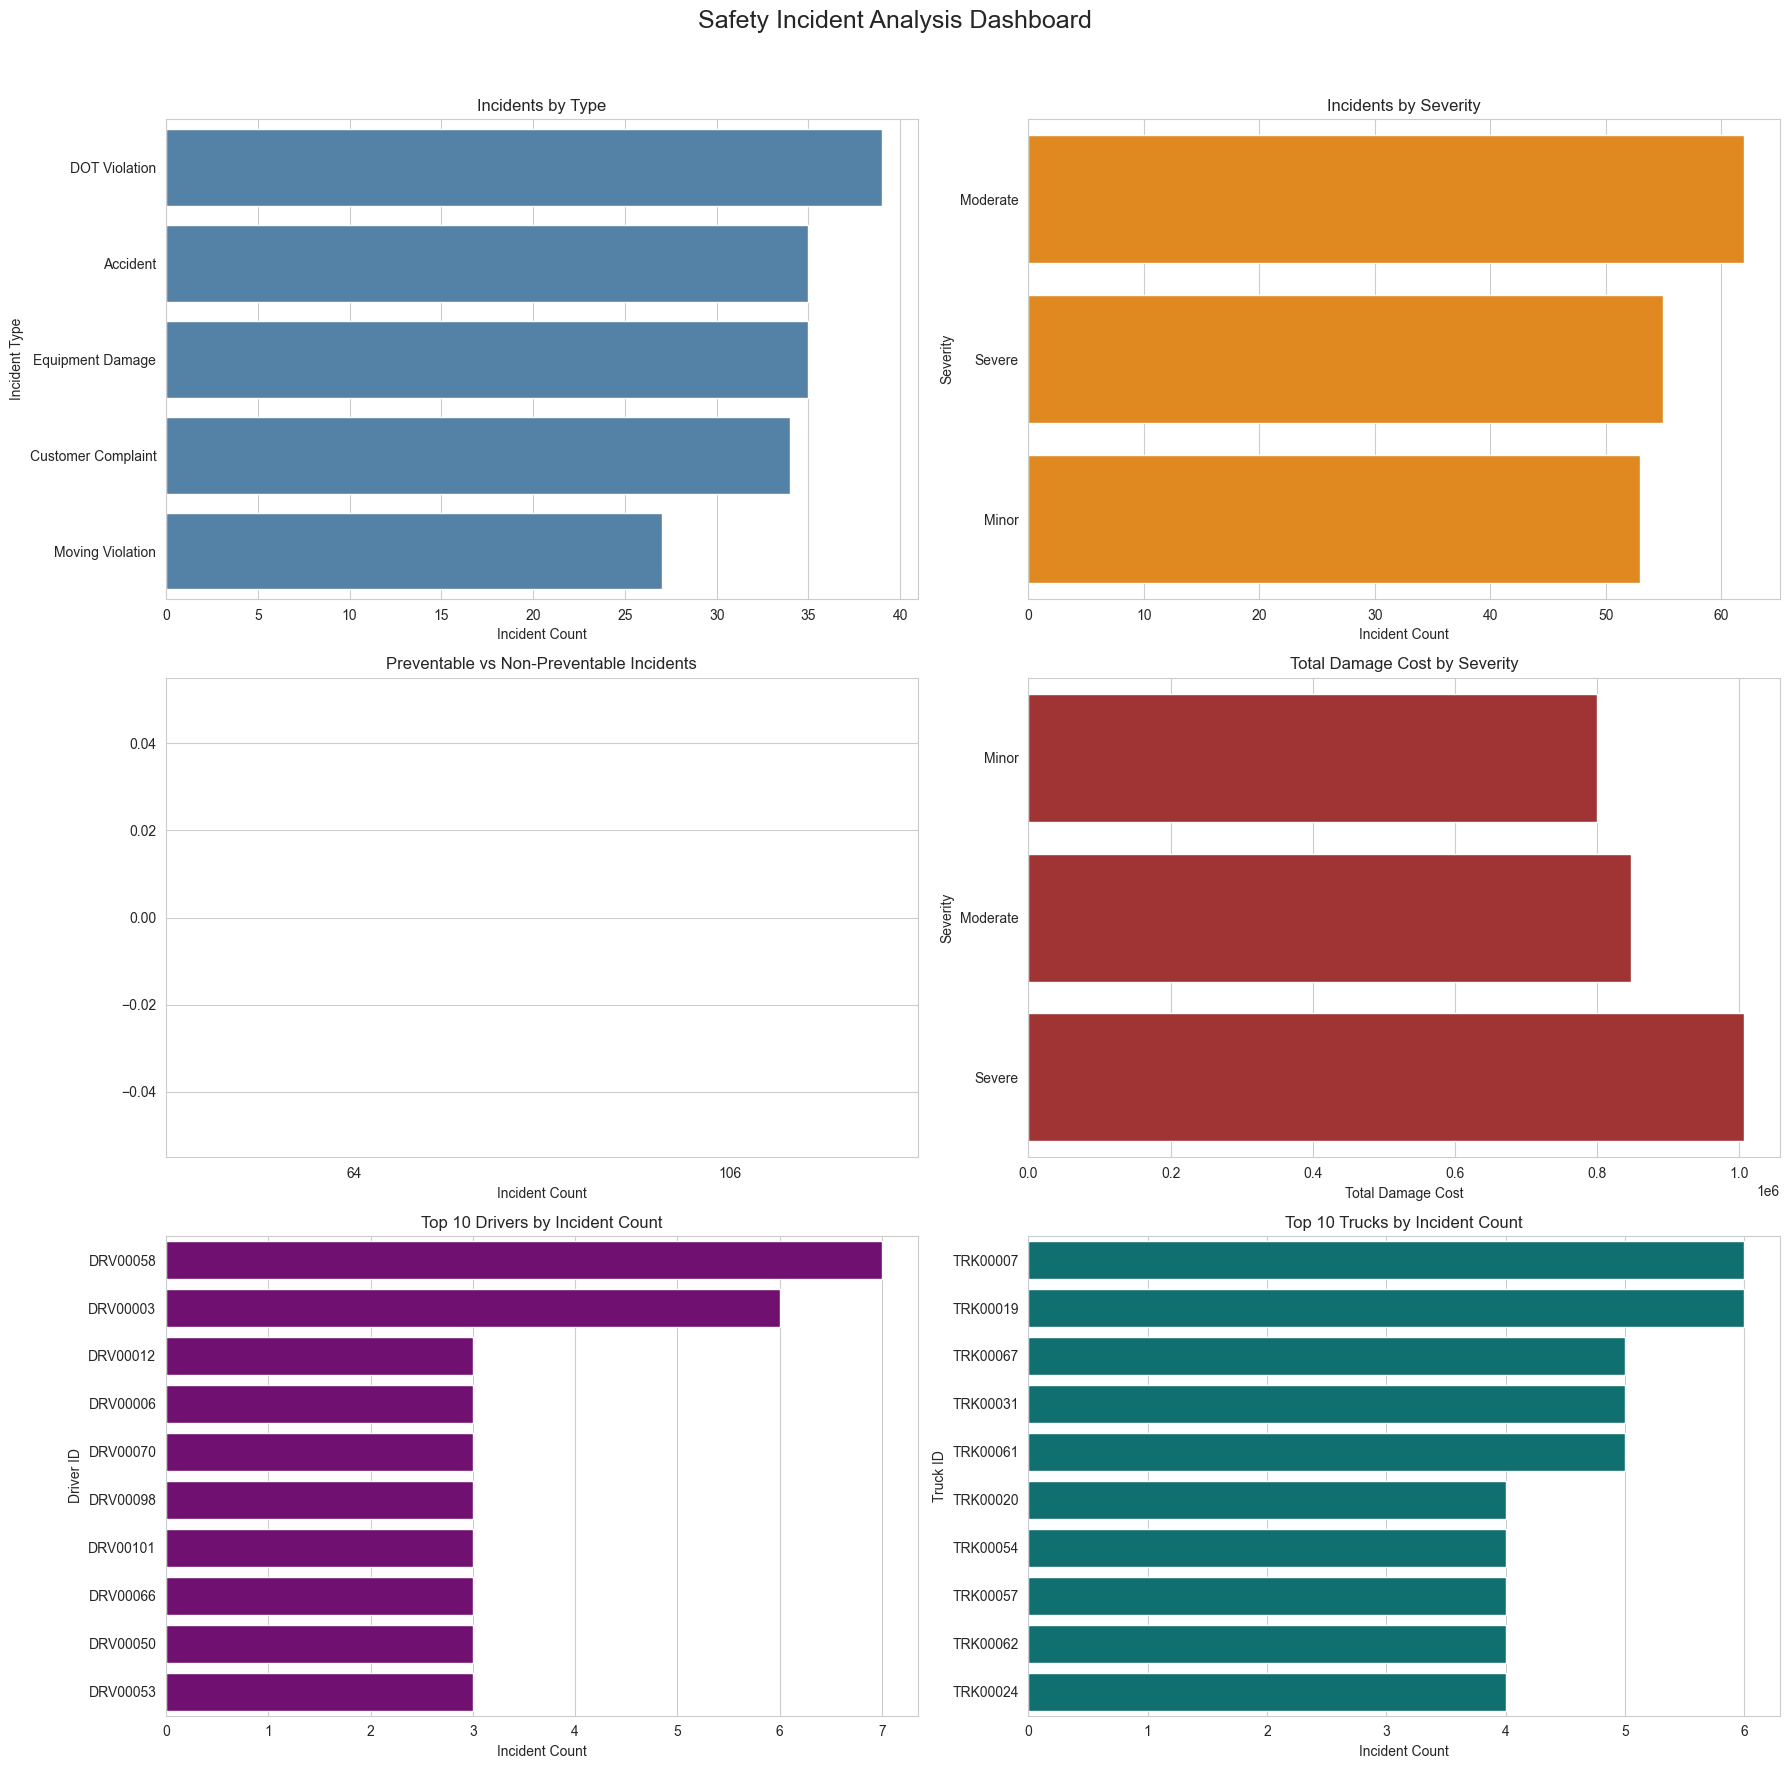

In [235]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle("Safety Incident Analysis Dashboard", fontsize=18)

# -----------------------------
# 1️⃣ Incidents by Type
# -----------------------------
incident_type_counts = safety_incident_df['incident_type'].value_counts().reset_index()
incident_type_counts.columns = ['incident_type', 'count']

sns.barplot(
    data=incident_type_counts,
    x='count',
    y='incident_type',
    color='steelblue',
    ax=axes[0, 0]
)
axes[0, 0].set_title("Incidents by Type")
axes[0, 0].set_xlabel("Incident Count")
axes[0, 0].set_ylabel("Incident Type")

# -----------------------------
# 2️⃣ Incidents by Severity
# -----------------------------
severity_counts = safety_incident_df['severity_level'].value_counts().reset_index()
severity_counts.columns = ['severity_level', 'count']

sns.barplot(
    data=severity_counts,
    x='count',
    y='severity_level',
    color='darkorange',
    ax=axes[0, 1]
)
axes[0, 1].set_title("Incidents by Severity")
axes[0, 1].set_xlabel("Incident Count")
axes[0, 1].set_ylabel("Severity")

# -----------------------------
# 3️⃣ Preventable vs Non-Preventable
# -----------------------------
preventable_counts = safety_incident_df['preventable_flag'].value_counts().reset_index()
preventable_counts.columns = ['preventable_flag', 'count']
preventable_counts['preventable_flag'] = preventable_counts['preventable_flag'].map(
    {1: 'Preventable', 0: 'Non-Preventable'}
)

sns.barplot(
    data=preventable_counts,
    x='count',
    y='preventable_flag',
    color='seagreen',
    ax=axes[1, 0]
)
axes[1, 0].set_title("Preventable vs Non-Preventable Incidents")
axes[1, 0].set_xlabel("Incident Count")
axes[1, 0].set_ylabel("")

# -----------------------------
# 4️⃣ Damage Cost by Severity
# -----------------------------
cost_by_severity = (
    safety_incident_df
    .groupby('severity_level')['Total_Damage_cost']
    .sum()
    .reset_index()
)

sns.barplot(
    data=cost_by_severity,
    x='Total_Damage_cost',
    y='severity_level',
    color='firebrick',
    ax=axes[1, 1]
)
axes[1, 1].set_title("Total Damage Cost by Severity")
axes[1, 1].set_xlabel("Total Damage Cost")
axes[1, 1].set_ylabel("Severity")

# -----------------------------
# 5️⃣ Top 10 Drivers by Incidents
# -----------------------------
top10_drivers = (
    driver_safety_summary
    .sort_values('total_incidents', ascending=False)
    .head(10)
)

sns.barplot(
    data=top10_drivers,
    x='total_incidents',
    y='driver_id',
    color='purple',
    ax=axes[2, 0]
)
axes[2, 0].set_title("Top 10 Drivers by Incident Count")
axes[2, 0].set_xlabel("Incident Count")
axes[2, 0].set_ylabel("Driver ID")

# -----------------------------
# 6️⃣ Top 10 Trucks by Incidents
# -----------------------------
top10_trucks = (
    truck_safety_summary
    .sort_values('total_incidents', ascending=False)
    .head(10)
)

sns.barplot(
    data=top10_trucks,
    x='total_incidents',
    y='truck_id',
    color='teal',
    ax=axes[2, 1]
)
axes[2, 1].set_title("Top 10 Trucks by Incident Count")
axes[2, 1].set_xlabel("Incident Count")
axes[2, 1].set_ylabel("Truck ID")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [236]:
def classify_driver_risk(row):
    if (
        (row['preventable_rate'] >= 0.5) or
        (row['at_fault_rate'] >= 0.5) or
        (row['severe_incidents'] >= 2)
    ):
        return 'High Risk'
    elif (
        (row['preventable_rate'] >= 0.25) or
        (row['at_fault_rate'] >= 0.25)
    ):
        return 'Medium Risk'
    else:
        return 'Low Risk'


driver_safety_summary['driver_risk_level'] = (
    driver_safety_summary.apply(classify_driver_risk, axis=1)
)

driver_safety_summary['driver_risk_level'].value_counts()


driver_risk_level
High Risk      61
Low Risk       26
Medium Risk     5
Name: count, dtype: int64

In [237]:
def classify_truck_risk(row):
    if (
        (row['preventable_rate'] >= 0.5) or
        (row['at_fault_rate'] >= 0.5) or
        (row['severe_incidents'] >= 2)
    ):
        return 'High Risk'
    elif (
        (row['preventable_rate'] >= 0.25) or
        (row['at_fault_rate'] >= 0.25)
    ):
        return 'Medium Risk'
    else:
        return 'Low Risk'


truck_safety_summary['truck_risk_level'] = (
    truck_safety_summary.apply(classify_truck_risk, axis=1)
)

truck_safety_summary['truck_risk_level'].value_counts()


truck_risk_level
High Risk      54
Low Risk       19
Medium Risk     7
Name: count, dtype: int64

In [238]:
monthly_incidents = (
    safety_incident_df.groupby('month')
    .agg(
        total_incidents=('incident_id', 'count'),
        total_damage_cost=('Total_Damage_cost', 'sum')
    )
    .reset_index()
    .sort_values('month')
)

monthly_incidents.head()


,month,total_incidents,total_damage_cost
0,1,21,227462.88
1,2,8,69320.02
2,3,12,163976.18
3,4,15,261465.82
4,5,17,378687.53


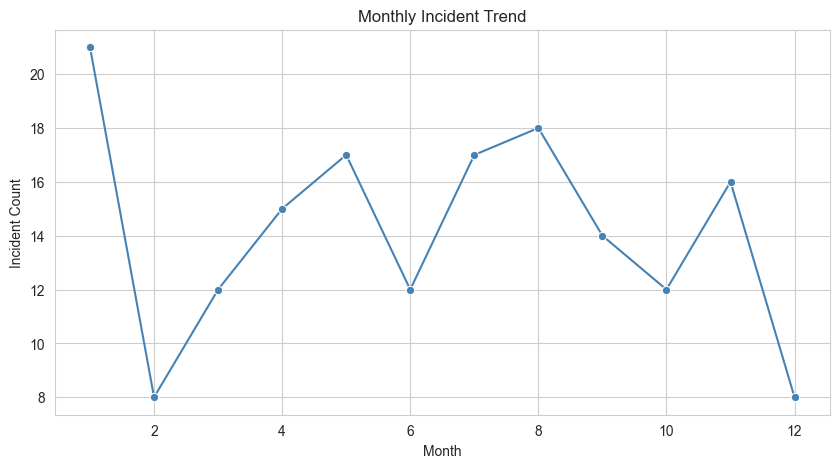

In [239]:
sns.set_style("whitegrid")

plt.figure(figsize=(10,5))
sns.lineplot(
    data=monthly_incidents,
    x='month',
    y='total_incidents',
    marker='o',
    color='steelblue'
)

plt.title("Monthly Incident Trend")
plt.xlabel("Month")
plt.ylabel("Incident Count")
plt.show()


**Seasonal Pattern Analysis**

In [240]:
def map_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'


monthly_incidents['season'] = monthly_incidents['month'].apply(map_season)

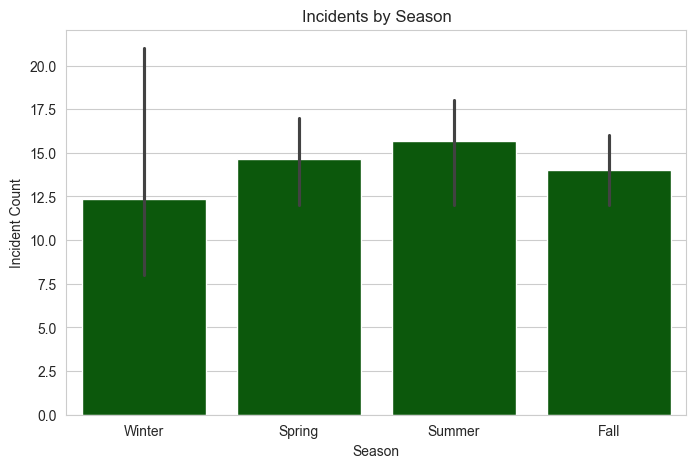

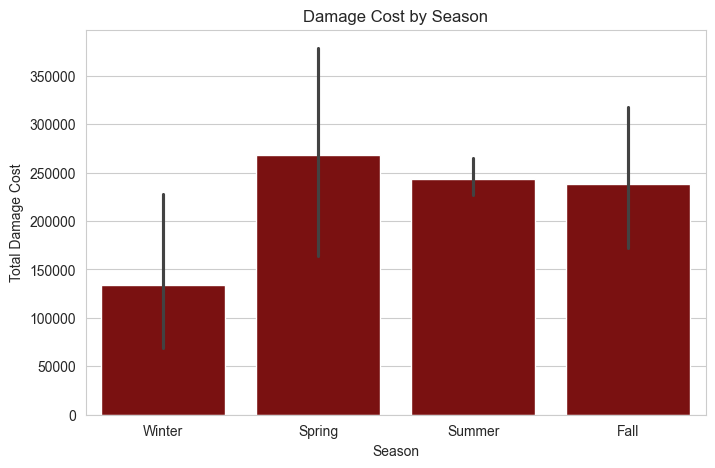

In [241]:
#Incidents by Season
plt.figure(figsize=(8,5))
sns.barplot(
    data=monthly_incidents,
    x='season',
    y='total_incidents',
    color='darkgreen'
)

#Damage Cost by Season
plt.title("Incidents by Season")
plt.xlabel("Season")
plt.ylabel("Incident Count")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(
    data=monthly_incidents,
    x='season',
    y='total_damage_cost',
    color='darkred'
)

plt.title("Damage Cost by Season")
plt.xlabel("Season")
plt.ylabel("Total Damage Cost")
plt.show()

## 9. Final Insights & Business Recommendations

This section consolidates insights across all analytical use cases and translates
them into actionable business takeaways. The focus is on decision support rather
than metric repetition.

---

### 9.1 Key Insights

- **Driver Performance**
  - Significant variation exists in driver efficiency, on-time reliability,
    and revenue per mile.
  - High-performing drivers consistently balance productivity and fuel efficiency,
    while low performers show cost or reliability risks.

- **Fleet & Truck Utilization**
  - Some trucks are overutilized, increasing maintenance and downtime risk,
    while others remain underutilized.
  - Operating cost per mile and profit per mile vary widely across the fleet.

- **Route Profitability**
  - High revenue routes are not always the most profitable once fuel and
    operating costs are considered.
  - Several routes show underpricing, high fuel dependency, or low revenue density,
    increasing long-term risk.

- **Fuel Efficiency**
  - Fleet-level MPG trends indicate areas of efficiency decline that may be linked
    to aging assets, maintenance gaps, or route conditions.
  - Certain routes consistently incur higher fuel cost per mile, indicating
    structural inefficiencies.

- **Revenue Trends**
  - Long-term growth analysis (CAGR) highlights entities with strong momentum
    as well as those with declining revenue despite high contribution.
  - Trend-based classification enables proactive prioritization rather than
    reactive performance review.

- **Safety & Seasonal Patterns**
  - Safety incidents and delays show time-based patterns that can be anticipated.
  - Seasonal fluctuations impact demand, cost, and risk simultaneously,
    requiring coordinated planning.

---

### 9.2 Business Recommendations

Based on the analysis, the following actions are recommended:

- **Performance Management**
  - Use driver leaderboards and revenue efficiency metrics to recognize
    top performers and target training for low-performing drivers.
  - Avoid mixing revenue scale with operational efficiency in performance scoring.

- **Fleet Optimization**
  - Rebalance truck utilization to reduce overuse and downtime risk.
  - Prioritize preventive maintenance for high-usage and low-MPG vehicles.

- **Route & Pricing Strategy**
  - Review underpriced and fuel-intensive routes for pricing adjustment or
    operational redesign.
  - Use profit per mile rather than total revenue as the primary route
    evaluation metric.

- **Fuel Cost Control**
  - Monitor MPG trends regularly to detect early efficiency degradation.
  - Assign more efficient vehicles to fuel-intensive routes where possible.

- **Strategic Planning**
  - Focus on entities with strong revenue growth and profitability momentum.
  - Use seasonal insights for capacity planning, staffing, and asset allocation.

---

### 9.3 Limitations

- Cost estimation relies on fleet-level efficiency benchmarks rather than
  direct route-level fuel measurement.
- External factors such as weather, traffic, and contract terms are not
  explicitly modeled.
- Data quality and completeness are dependent on the source operational dataset.

These limitations do not invalidate the analysis but should be considered
when operationalizing recommendations.

---

### 9.4 Next Steps

Potential extensions of this project include:
- Integration of real-time fuel and telematics data
- Predictive modeling for fuel cost, delays, and maintenance
- Optimization models for route assignment and fleet sizing
- Dashboard automation for continuous monitoring

---

**Conclusion**

This project demonstrates how structured logistics analytics can move beyond
reporting to enable informed, data-driven operational and strategic decisions.
